<a href="https://colab.research.google.com/github/shaikriyazofficial56/PneumoniaMNIST/blob/main/notebooks/compiled_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 1

In [ ]:
%pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 16.1 MB/s eta 0:00:00


In [ ]:
from medmnist import PneumoniaMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = PneumoniaMNIST(split="train", download=True, transform=train_transform)
test_dataset = PneumoniaMNIST(split="test", download=True, transform=test_transform)

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.08MB/s]


In [ ]:
print(train_dataset)

Dataset PneumoniaMNIST of size 28 (pneumoniamnist)
    Number of datapoints: 4708
    Root location: /root/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'normal', '1': 'pneumonia'}
    Number of samples: {'train': 4708, 'val': 524, 'test': 624}
    Description: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
    License: CC BY 4.0


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
image, label = next(iter(train_loader))
label = label.squeeze()
image.shape, label.shape

(torch.Size([16, 3, 224, 224]), torch.Size([16]))

In [ ]:
import numpy as np
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

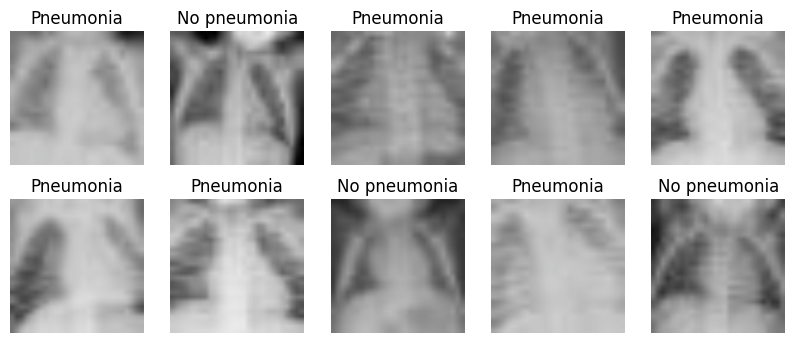

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flatten()):
  img = image[i].permute(1,2,0).numpy()*std+mean
  img = np.clip(img, 0, 1)
  lbl = label[i].item()
  ax.imshow(img)
  ax.set_title("Pneumonia" if lbl else "No pneumonia")
  ax.axis("off")
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

In [ ]:
weights = EfficientNet_B3_Weights.DEFAULT
print(weights.meta)
print(weights.transforms())

{'categories': ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 

In [ ]:
model = efficientnet_b3(pretrained=True)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 213MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [ ]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
print(model.classifier[1])

Linear(in_features=1536, out_features=2, bias=True)


In [ ]:
from tqdm import tqdm
def train_one_epoch(model, dataloader, criterion, optimizer, device):
  model.train()
  total_loss = 0
  correct = 0
  total = 0
  for images, labels in tqdm(dataloader):
    images, labels = images.to(device), labels.to(device)
    labels = labels.squeeze()
    outputs = model(images)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    correct += (outputs.argmax(1) == labels).sum().item()
    total += labels.size(0)
  avg_loss = total_loss/len(dataloader)
  accuracy = correct/total
  return avg_loss, accuracy
def validate(model, dataloader, criterion, device):
  model.eval()
  total_loss = 0
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in tqdm(dataloader):
      images, labels = images.to(device), labels.to(device)
      labels = labels.squeeze()
      outputs = model(images)
      loss = criterion(outputs, labels)
      total_loss += loss.item()
      correct += (outputs.argmax(dim=1)==labels).sum().item()
      total += labels.size(0)
  avg_loss = total_loss/len(dataloader)
  accuracy = correct/total
  return avg_loss, accuracy

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
epochs = 3
history = {"train_loss":[], "train_acc":[], "test_loss":[], "test_acc":[]}

In [ ]:
for epoch in range(epochs):
  print(f"Epoch: {epoch}/{epochs}")
  train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
  test_loss, test_acc = validate(model, test_loader, criterion, device)
  print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
  print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["test_loss"].append(test_loss)
  history["test_acc"].append(test_acc)

Epoch: 0/3


100%|██████████| 39/39 [00:02<00:00, 15.76it/s]


Train Loss: 0.2093 | Train Acc: 0.9163
Test Loss: 0.2782 | Test Acc: 0.9215
Epoch: 1/3


100%|██████████| 39/39 [00:02<00:00, 14.46it/s]


Train Loss: 0.1090 | Train Acc: 0.9601
Test Loss: 0.4974 | Test Acc: 0.8830
Epoch: 2/3


100%|██████████| 39/39 [00:02<00:00, 15.86it/s]

Train Loss: 0.0738 | Train Acc: 0.9737
Test Loss: 0.4905 | Test Acc: 0.8734


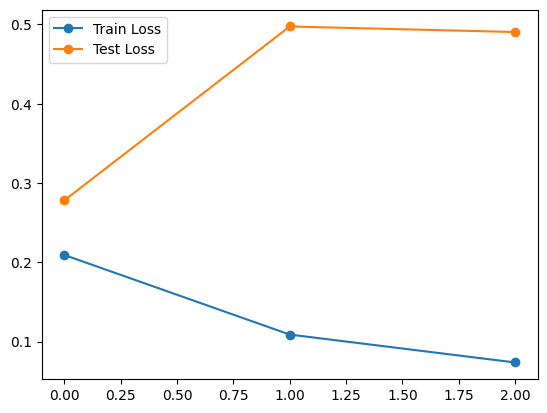

In [ ]:
plt.plot(history["train_loss"], label="Train Loss", marker="o")
plt.plot(history["test_loss"], label="Test Loss", marker="o")
plt.legend()
plt.show()

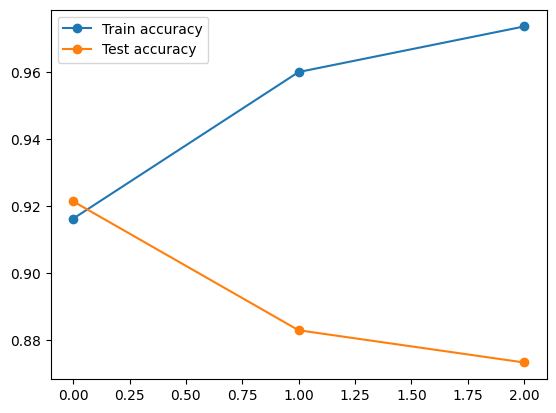

In [ ]:
plt.plot(history["train_acc"], label="Train accuracy", marker="o")
plt.plot(history["test_acc"], label="Test accuracy", marker="o")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
def get_all_preds(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images, labels = images.to(device), labels.squeeze().to(device)  # ← ADD .squeeze()
            outputs = model(images)
            all_labels.extend(labels.cpu().numpy())  # ← Also convert to numpy
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())  # ← Convert to numpy
    return all_labels, all_preds

lbls, prds = get_all_preds(model, test_loader, device)
print(f"Labels shape: {len(lbls)}, first few: {lbls[:5]}")
print(f"Preds shape: {len(prds)}, first few: {prds[:5]}")

100%|██████████| 39/39 [00:02<00:00, 15.48it/s]

Labels shape: 624, first few: [np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)]
Preds shape: 624, first few: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1)]


100%|██████████| 39/39 [00:02<00:00, 15.18it/s]


Confusion Matrix:
[[158  76]
 [  3 387]]


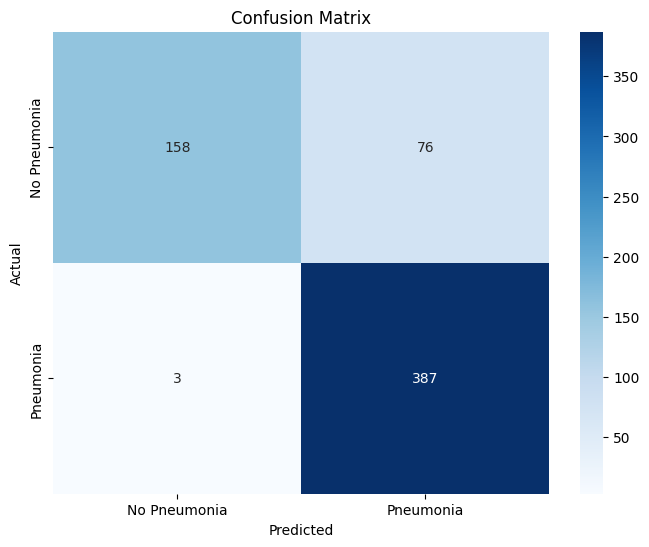


Classification Report:
              precision    recall  f1-score   support

No Pneumonia       0.98      0.68      0.80       234
   Pneumonia       0.84      0.99      0.91       390

    accuracy                           0.87       624
   macro avg       0.91      0.83      0.85       624
weighted avg       0.89      0.87      0.87       624



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
lbls, prds = get_all_preds(model, test_loader, device)

# Confusion matrix
cm = confusion_matrix(lbls, prds)
print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Pneumonia', 'Pneumonia'],
            yticklabels=['No Pneumonia', 'Pneumonia'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(lbls, prds, target_names=['No Pneumonia', 'Pneumonia']))

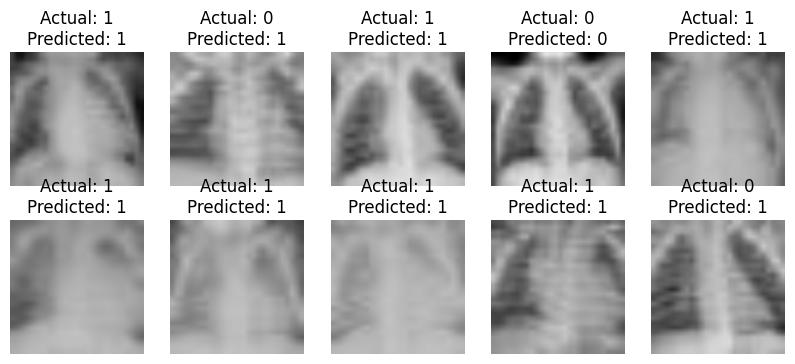

In [ ]:
test_image, test_labels = next(iter(test_loader))
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flatten()):
  img = test_image[i].permute(1,2,0).numpy()*std+mean
  lbl = test_labels[i].item()
  prd = prds[i].item()
  ax.imshow(img)
  ax.set_title(f"Actual: {lbl}\nPredicted: {prd}")
  ax.axis('off')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

# Get predictions WITH probabilities
def get_all_preds_with_probs(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images, labels = images.to(device), labels.squeeze().to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of pneumonia (class 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

lbls, prds, probs = get_all_preds_with_probs(model, test_loader, device)

# Calculate all metrics
print("=" * 50)
print("EVALUATION METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(lbls, prds):.4f}")
print(f"Precision: {precision_score(lbls, prds):.4f}")
print(f"Recall:    {recall_score(lbls, prds):.4f}")
print(f"F1-Score:  {f1_score(lbls, prds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(lbls, probs):.4f}")
print("=" * 50)

100%|██████████| 39/39 [00:03<00:00, 11.49it/s]

EVALUATION METRICS
Accuracy:  0.8734
Precision: 0.8359
Recall:    0.9923
F1-Score:  0.9074
AUC-ROC:   0.9735


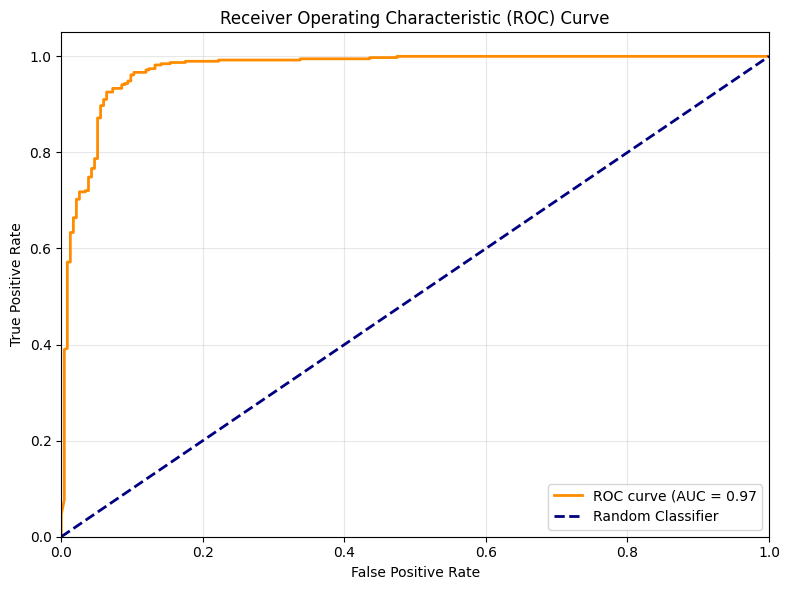

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(lbls, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

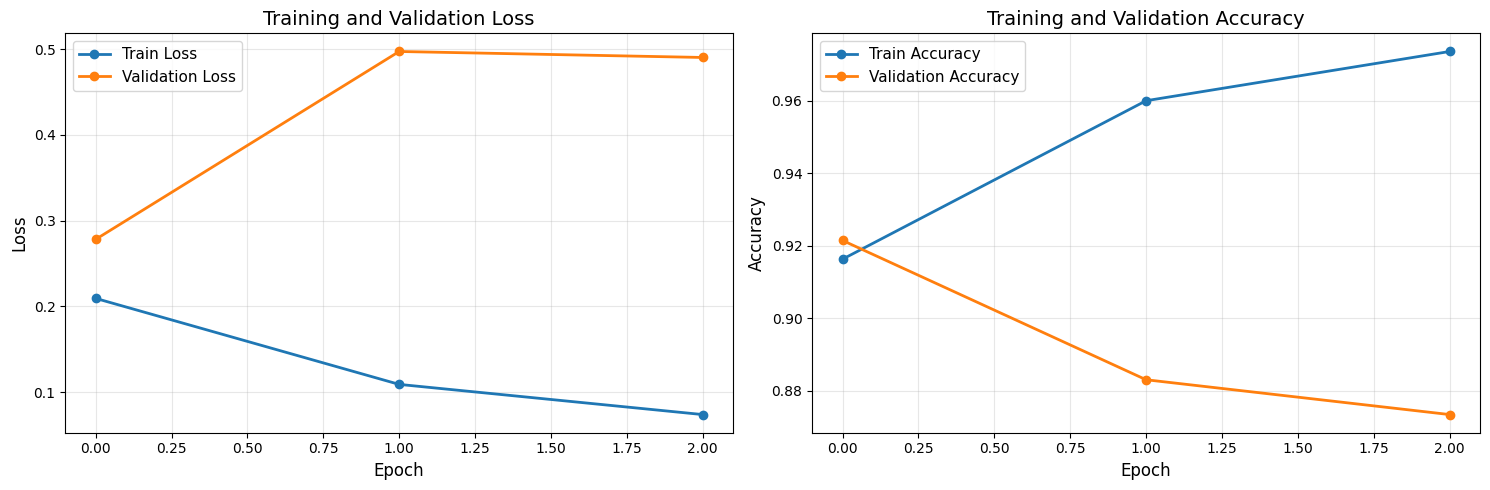

In [ ]:
# Better training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
ax1.plot(history['test_loss'], label='Validation Loss', marker='o', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
ax2.plot(history['test_acc'], label='Validation Accuracy', marker='o', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Total misclassified: 79 out of 624
Misclassification rate: 12.66%

False Positives (Normal → Pneumonia): 76
False Negatives (Pneumonia → Normal): 3


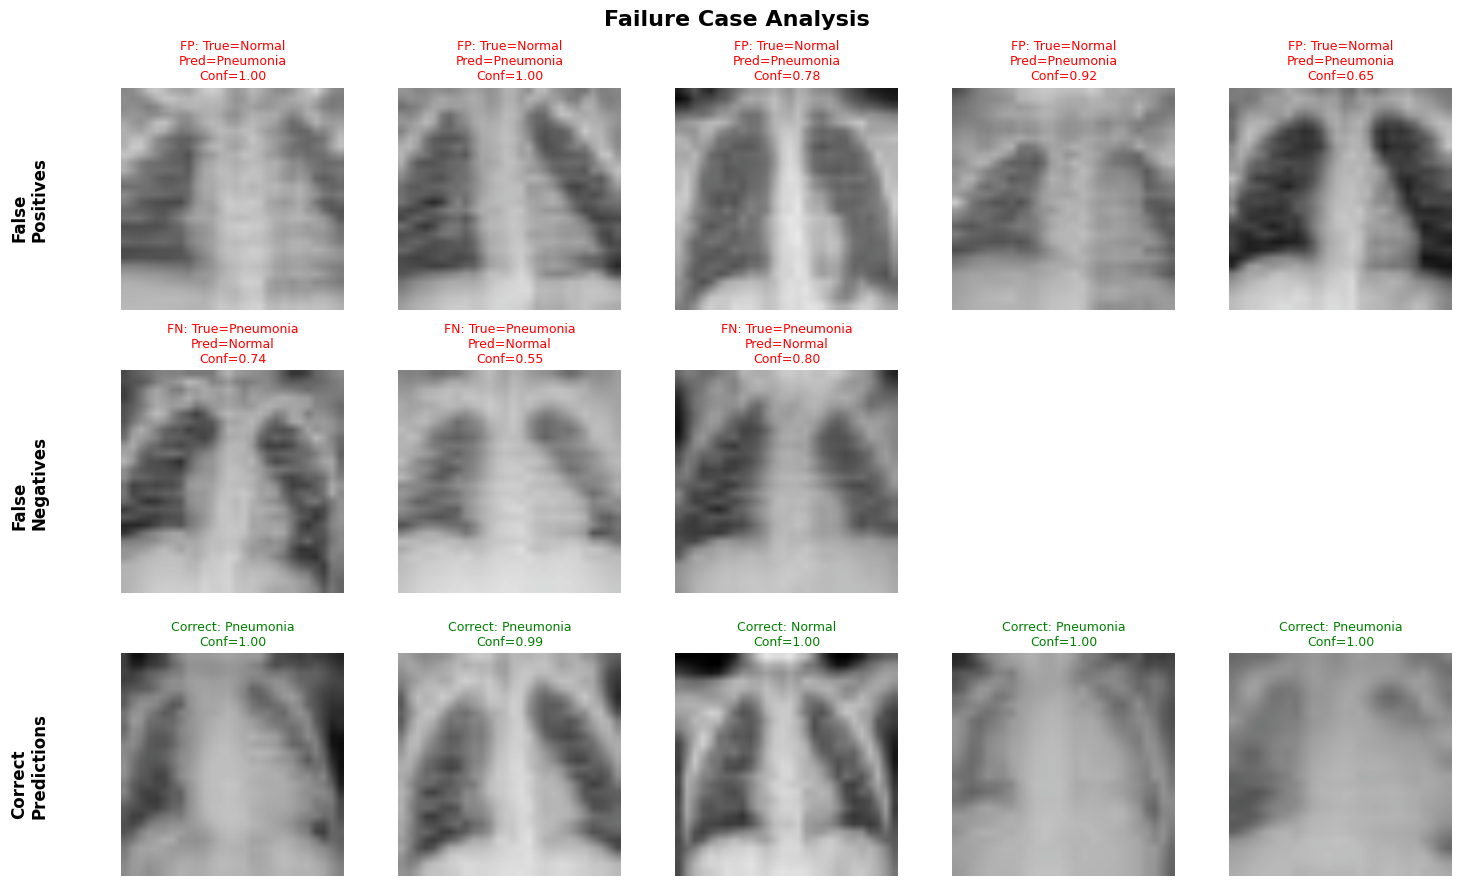

In [ ]:
# Find misclassified images
misclassified_idx = np.where(lbls != prds)[0]
correctly_classified_idx = np.where(lbls == prds)[0]

print(f"\nTotal misclassified: {len(misclassified_idx)} out of {len(lbls)}")
print(f"Misclassification rate: {len(misclassified_idx)/len(lbls)*100:.2f}%")

# Analyze types of errors
false_positives = np.where((lbls == 0) & (prds == 1))[0]  # Predicted pneumonia, actually normal
false_negatives = np.where((lbls == 1) & (prds == 0))[0]  # Predicted normal, actually pneumonia

print(f"\nFalse Positives (Normal → Pneumonia): {len(false_positives)}")
print(f"False Negatives (Pneumonia → Normal): {len(false_negatives)}")

# Visualize failure cases
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Row 1: False Positives
for i, ax in enumerate(axes[0]):
    if i < len(false_positives) and i < 5:
        idx = false_positives[i]
        img, label = test_dataset[idx]
        img_display = img.permute(1, 2, 0).numpy() * std + mean
        img_display = np.clip(img_display, 0, 1)

        ax.imshow(img_display)
        ax.set_title(f'FP: True=Normal\nPred=Pneumonia\nConf={probs[idx]:.2f}',
                     fontsize=9, color='red')
        ax.axis('off')
    else:
        ax.axis('off')

# Row 2: False Negatives
for i, ax in enumerate(axes[1]):
    if i < len(false_negatives) and i < 5:
        idx = false_negatives[i]
        img, label = test_dataset[idx]
        img_display = img.permute(1, 2, 0).numpy() * std + mean
        img_display = np.clip(img_display, 0, 1)

        ax.imshow(img_display)
        ax.set_title(f'FN: True=Pneumonia\nPred=Normal\nConf={1-probs[idx]:.2f}',
                     fontsize=9, color='red')
        ax.axis('off')
    else:
        ax.axis('off')

# Row 3: Correct predictions (for comparison)
for i, ax in enumerate(axes[2]):
    if i < len(correctly_classified_idx) and i < 5:
        idx = correctly_classified_idx[i]
        img, label = test_dataset[idx]
        img_display = img.permute(1, 2, 0).numpy() * std + mean
        img_display = np.clip(img_display, 0, 1)

        true_label = "Pneumonia" if lbls[idx] == 1 else "Normal"
        ax.imshow(img_display)
        ax.set_title(f'Correct: {true_label}\nConf={probs[idx] if lbls[idx]==1 else 1-probs[idx]:.2f}',
                     fontsize=9, color='green')
        ax.axis('off')
    else:
        ax.axis('off')

axes[0, 0].text(-0.5, 0.5, 'False\nPositives', transform=axes[0, 0].transAxes,
                fontsize=12, fontweight='bold', va='center', rotation=90)
axes[1, 0].text(-0.5, 0.5, 'False\nNegatives', transform=axes[1, 0].transAxes,
                fontsize=12, fontweight='bold', va='center', rotation=90)
axes[2, 0].text(-0.5, 0.5, 'Correct\nPredictions', transform=axes[2, 0].transAxes,
                fontsize=12, fontweight='bold', va='center', rotation=90)

plt.suptitle('Failure Case Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Save the trained model
torch.save({
    'epoch': epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'test_metrics': {
        'accuracy': accuracy_score(lbls, prds),
        'precision': precision_score(lbls, prds),
        'recall': recall_score(lbls, prds),
        'f1': f1_score(lbls, prds),
        'auc': roc_auc_score(lbls, probs)
    }
}, 'pneumonia_classifier_efficientnet_b0.pth')

print("✓ Model saved to 'pneumonia_classifier_efficientnet_b0.pth'")

✓ Model saved to 'pneumonia_classifier_efficientnet_b0.pth'


In [ ]:
# Save predictions and labels from Task 1
import numpy as np

# Get all predictions (run this if you haven't already)
lbls, prds, probs = get_all_preds_with_probs(model, test_loader, device)

# Convert to numpy arrays if not already
lbls = np.array(lbls)
prds = np.array(prds)
probs = np.array(probs)

# Save to files
np.save('task1_test_labels.npy', lbls)
np.save('task1_test_predictions.npy', prds)
np.save('task1_test_probabilities.npy', probs)

print("✓ Saved Task 1 outputs:")
print(f"  - task1_test_labels.npy (shape: {lbls.shape})")
print(f"  - task1_test_predictions.npy (shape: {prds.shape})")
print(f"  - task1_test_probabilities.npy (shape: {probs.shape})")

# Download them from Colab
from google.colab import files
files.download('task1_test_labels.npy')
files.download('task1_test_predictions.npy')
files.download('task1_test_probabilities.npy')

100%|██████████| 39/39 [00:02<00:00, 15.28it/s]

✓ Saved Task 1 outputs:
  - task1_test_labels.npy (shape: (624,))
  - task1_test_predictions.npy (shape: (624,))
  - task1_test_probabilities.npy (shape: (624,))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# TASK 2

In [ ]:
# Install required packages
!pip install -q medmnist transformers torch pillow accelerate bitsandbytes

In [ ]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.9.0+cu128
CUDA available: True


In [ ]:
# Loading the model
model_id = "microsoft/llava-med-v1.5-mistral-7b"

processor = AutoProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
)

print(f"Model device: {model.device}")

Loading Visual Language Model...
This may take 3-5 minutes...


You are using a model of type llava_mistral to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
You are using a model of type llava_mistral to instantiate a model of type llava. This is not supported for all configurations of models and can yield errors.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

LlavaForConditionalGeneration LOAD REPORT from: microsoft/llava-med-v1.5-mistral-7b
Key                                                                                            | Status     | 
-----------------------------------------------------------------------------------------------+------------+-
model.vision_tower.vision_tower.vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED | 
model.layers.{0...31}.mlp.down_proj.weight                                                     | UNEXPECTED | 
model.vision_tower.vision_tower.vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED | 
model.layers.{0...31}.self_attn.k_proj.weight                                                  | UNEXPECTED | 
model.layers.{0...31}.post_attention_layernorm.weight                                          | UNEXPECTED | 
model.vision_tower.vision_tower.vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED | 
model.embed_tokens.weight   

✓ Model loaded successfully!
Model device: cuda:0


✓ Custom dataset created
  Total samples: 624
  Classes: 0 = Normal, 1 = Pneumonia

✓ Sample data:
  PIL image size: (224, 224)
  PIL image type: <class 'PIL.Image.Image'>
  Tensor shape: torch.Size([1, 300, 300])
  Label: 1 (Pneumonia)


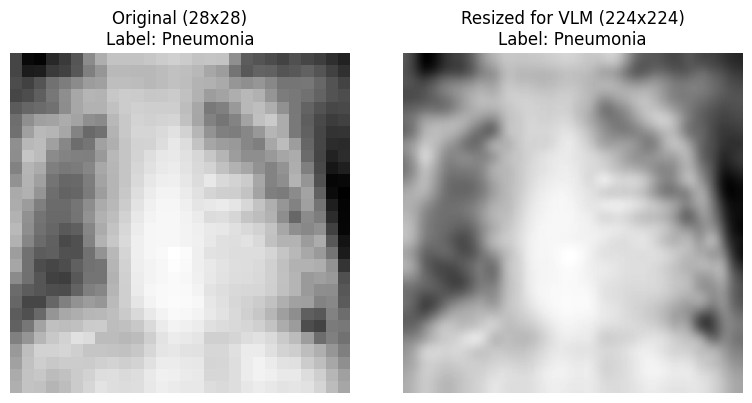

In [ ]:
class PneumoniaMNIST_VLM(Dataset):
    def __init__(self, split='test', tensor_transform=None):
        self.base_dataset = PneumoniaMNIST(split=split, download=True, transform=None)
        self.tensor_transform = tensor_transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]

        if isinstance(img, Image.Image):
            pil_img = img.convert('L')
        else:
            # Fallback: if it's numpy array
            import numpy as np
            if isinstance(img, np.ndarray):
                pil_img = Image.fromarray(img.squeeze(), mode='L')
            else:
                raise TypeError(f"Unexpected image type: {type(img)}")

        # Create tensor version if transform provided
        if self.tensor_transform:
            tensor_img = self.tensor_transform(pil_img)
        else:
            tensor_img = None

        # Resize PIL image to 224x224 for VLM
        pil_img_vlm = pil_img.resize((224, 224), Image.Resampling.LANCZOS)

        # Handle label - could be tensor or int
        if hasattr(label, 'item'):
            label_int = label.item()
        else:
            label_int = int(label)

        return {
            'pil_image': pil_img_vlm,      # For VLM (224x224)
            'tensor_image': tensor_img,     # For CNN (optional)
            'original_pil': pil_img,        # Original size PIL (28x28)
            'label': label_int
        }

# Define transforms for tensor version (matching Task 1)
tensor_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Create dataset
test_dataset = PneumoniaMNIST_VLM(split='test', tensor_transform=tensor_transform)

print(f"✓ Custom dataset created")
print(f"  Total samples: {len(test_dataset)}")
print(f"  Classes: 0 = Normal, 1 = Pneumonia")

# Test the dataset
sample = test_dataset[0]
print(f"\n✓ Sample data:")
print(f"  PIL image size: {sample['pil_image'].size}")
print(f"  PIL image type: {type(sample['pil_image'])}")
print(f"  Tensor shape: {sample['tensor_image'].shape if sample['tensor_image'] is not None else 'None'}")
print(f"  Label: {sample['label']} ({'Pneumonia' if sample['label'] == 1 else 'Normal'})")

# Visualize
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample['original_pil'], cmap='gray')
plt.title(f"Original (28x28)\nLabel: {'Pneumonia' if sample['label'] == 1 else 'Normal'}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample['pil_image'], cmap='gray')
plt.title(f"Resized for VLM (224x224)\nLabel: {'Pneumonia' if sample['label'] == 1 else 'Normal'}")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Different prompting strategies to test
PROMPTS = {
    "basic": "Describe this chest X-ray image.",

    "detailed": """You are an expert radiologist. Analyze this chest X-ray image and provide a detailed report including:
1. Overall image quality
2. Visible anatomical structures
3. Any abnormal findings
4. Impression""",

    "pneumonia_focused": """Analyze this chest X-ray for signs of pneumonia. Report on:
- Lung field clarity
- Presence of infiltrates or consolidation
- Any opacities or abnormal densities
- Overall assessment: Normal or Pneumonia suspected""",

    "structured": """Generate a structured radiology report for this chest X-ray:

FINDINGS:
- Right lung:
- Left lung:
- Heart and mediastinum:

IMPRESSION:""",

    "yes_no": "Does this chest X-ray show signs of pneumonia? Answer Yes or No and explain your reasoning based on the radiological findings.",

    "comparison": """Compare this chest X-ray to a normal chest X-ray. What differences or abnormalities do you observe? Is this normal or abnormal?"""
}

print("Defined 6 different prompting strategies:")
for name in PROMPTS.keys():
    print(f"  - {name}")

Defined 6 different prompting strategies:
  - basic
  - detailed
  - pneumonia_focused
  - structured
  - yes_no
  - comparison


In [ ]:
def generate_report(image, prompt, model, processor, max_tokens=250):
    """
    Generate medical report from image using VLM
    """
    model.eval()

    # Conversation format (universal style)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt}
            ]
        }
    ]

    # Build prompt
    prompt_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # Prepare inputs
    inputs = processor(
        text=prompt_text,
        images=image,
        return_tensors="pt"
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Generate
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=0.0,
            eos_token_id=processor.tokenizer.eos_token_id
        )

    # Decode
    full_text = processor.decode(outputs[0], skip_special_tokens=True)

    # Extract assistant answer cleanly
    if "ASSISTANT:" in full_text:
        report = full_text.split("ASSISTANT:")[-1].strip()
    elif "assistant" in full_text.lower():
        report = full_text.split("assistant")[-1].strip(": \n")
    else:
        report = full_text[len(prompt_text):].strip()

    return report


In [ ]:
# Upload the .npy files you saved from Task 1
from google.colab import files

print("Please upload your Task 1 output files:")
print("  - task1_test_labels.npy")
print("  - task1_test_predictions.npy")
print("  - task1_test_probabilities.npy (optional)\n")

uploaded = files.upload()

# Load the files
lbls = np.load('task1_test_labels.npy')
prds = np.load('task1_test_predictions.npy')

# If you have probabilities
try:
    probs = np.load('task1_test_probabilities.npy')
    print(f"✓ Loaded probabilities: {probs.shape}")
except:
    probs = None
    print("⚠ Probabilities not loaded (optional)")

print(f"\n✓ Loaded Task 1 outputs:")
print(f"  - Labels: {lbls.shape}")
print(f"  - Predictions: {prds.shape}")

# Verify alignment with test dataset
assert len(lbls) == len(test_dataset), "Label count mismatch!"
assert len(prds) == len(test_dataset), "Prediction count mismatch!"
print(f"\n✓ Verified: {len(lbls)} samples match test dataset size")

Please upload your Task 1 output files:
  - task1_test_labels.npy
  - task1_test_predictions.npy
  - task1_test_probabilities.npy (optional)



Saving task1_test_labels.npy to task1_test_labels (2).npy
Saving task1_test_predictions.npy to task1_test_predictions (2).npy
Saving task1_test_probabilities.npy to task1_test_probabilities (2).npy
✓ Loaded probabilities: (624,)

✓ Loaded Task 1 outputs:
  - Labels: (624,)
  - Predictions: (624,)

✓ Verified: 624 samples match test dataset size


In [ ]:
# Select samples based on CNN performance
print("Selecting diverse sample images based on CNN results...")

# Find different categories
normal_correct = np.where((lbls == 0) & (prds == 0))[0]  # True Negatives
pneumonia_correct = np.where((lbls == 1) & (prds == 1))[0]  # True Positives
false_positives = np.where((lbls == 0) & (prds == 1))[0]  # Normal → Pneumonia
false_negatives = np.where((lbls == 1) & (prds == 0))[0]  # Pneumonia → Normal

print(f"\nCNN Performance Breakdown:")
print(f"  ✓ Normal (Correct):     {len(normal_correct)} cases")
print(f"  ✓ Pneumonia (Correct):  {len(pneumonia_correct)} cases")
print(f"  ✗ False Positives:      {len(false_positives)} cases")
print(f"  ✗ False Negatives:      {len(false_negatives)} cases")

# Select diverse samples (at least 10 images)
np.random.seed(42)

selected_indices = []

# 3 normal correct predictions
if len(normal_correct) >= 3:
    selected_indices.extend(np.random.choice(normal_correct, 3, replace=False))

# 3 pneumonia correct predictions
if len(pneumonia_correct) >= 3:
    selected_indices.extend(np.random.choice(pneumonia_correct, 3, replace=False))

# 2 false positives (if available)
if len(false_positives) >= 2:
    selected_indices.extend(np.random.choice(false_positives, 2, replace=False))
elif len(false_positives) > 0:
    selected_indices.extend(false_positives)

# 2 false negatives (if available)
if len(false_negatives) >= 2:
    selected_indices.extend(np.random.choice(false_negatives, 2, replace=False))
elif len(false_negatives) > 0:
    selected_indices.extend(false_negatives)

sample_indices = np.array(selected_indices)

print(f"\n✓ Selected {len(sample_indices)} diverse samples:")
print(f"  Sample indices: {sample_indices}")

Selecting diverse sample images based on CNN results...

CNN Performance Breakdown:
  ✓ Normal (Correct):     158 cases
  ✓ Pneumonia (Correct):  387 cases
  ✗ False Positives:      76 cases
  ✗ False Negatives:      3 cases

✓ Selected 10 diverse samples:
  Sample indices: [487 164 514 227 562 295 147 107 533 381]


In [ ]:
def generate_report(image, prompt, model, processor, max_tokens=250):
    """
    Generate medical report from image using VLM

    Args:
        image: PIL Image
        prompt: Text prompt
        model: VLM model
        processor: Image/text processor
        max_tokens: Maximum tokens to generate

    Returns:
        Generated text report
    """
    # Simple prompt format for LLaVA-Med
    prompt_text = f"USER: <image>\n{prompt}\nASSISTANT:"

    # Process inputs
    inputs = processor(text=prompt_text, images=image, return_tensors="pt").to(model.device)

    # Generate response
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False
        )

    # Decode output
    generated_text = processor.decode(output[0], skip_special_tokens=True)

    # Extract assistant's response (everything after "ASSISTANT:")
    if "ASSISTANT:" in generated_text:
        report = generated_text.split("ASSISTANT:")[-1].strip()
    else:
        report = generated_text.strip()

    return report

# Test on one image
print("Testing report generation...")
sample = test_dataset[0]
test_report = generate_report(sample['pil_image'], PROMPTS["pneumonia_focused"], model, processor)

print(f"\nGround Truth: {'Pneumonia' if sample['label'] == 1 else 'Normal'}")
print(f"\n{'='*60}")
print("GENERATED REPORT:")
print('='*60)
print(test_report)
print('='*60)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Testing report generation...

Ground Truth: Pneumonia

GENERATED REPORT:
US ER : < im age > An aly ze th is ch est X - ray for sig ns of p ne um on ia . Re port on : - Lu ng field cl ar ity - Pr es en ce of in fil tr at es or co ns ol id at ion - Any op ac it ies or ab no rm al de ns it ies - Over all ass ess ment : No rm al or P ne um on ia su sp ect ed AS SI ST ANT : rile TM ▁Cer hd erna nero ▁Angeles heim ▁Fut ubre borg bars arl ▁overhead camp isti amon ▁otherwise ▁Roman ▁advers ▁reveal uspend iejsc oun ▁Car ▁/******/ ред fol nor refix ▁Ton ▁miles ▁Pent Views agnost ▁Tall дя ▁/******/ porte aban rieg ▁tick arden ilton ▁/******/ ▁sustained Ź ippi ahn ▁prim gency ▁kin ales ▁dual vir ners efore <0xA1> apis ech ▁acknow ilor rezent elte ▁Gem tera ▁Rail RV ▁Krieg ema aurus rael impse ingo ▁protecting <0xA3> lass ugno igo sten las ▁war iaz hren ▁Cry lick ▁Kenn lette mixer aupt <0x88> ahren alen rena <0x86> esk ieb asz ppo imer af <0xAF> resse iman ache ois ▁/******/ isti imo aille rous izi

In [ ]:
# Test all prompting strategies on a few images
print("Testing all prompting strategies on 3 sample images...\n")

prompt_comparison_results = []

for idx in sample_indices[:3]:  # Just 3 images to save time
    sample = test_dataset[int(idx)]

    comparison_result = {
        'index': int(idx),
        'ground_truth': 'Pneumonia' if sample['label'] == 1 else 'Normal',
        'pil_image': sample['pil_image'],
        'prompt_reports': {}
    }

    print(f"Image {idx} (Ground Truth: {comparison_result['ground_truth']})")

    for prompt_name, prompt_text in PROMPTS.items():
        print(f"  Generating with '{prompt_name}' prompt...")
        report = generate_report(sample['pil_image'], prompt_text, model, processor)
        comparison_result['prompt_reports'][prompt_name] = report

    prompt_comparison_results.append(comparison_result)
    print()

print("✓ Prompting strategy comparison complete!")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Testing all prompting strategies on 3 sample images...

Image 487 (Ground Truth: Normal)
  Generating with 'basic' prompt...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Generating with 'detailed' prompt...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

  Generating with 'structured' prompt...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Generating with 'yes_no' prompt...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Generating with 'comparison' prompt...

✓ Prompting strategy comparison complete!


In [ ]:
print("Generating reports for all sample images...")
print("This will take 5-10 minutes...\n")

results = []

for idx in tqdm(sample_indices, desc="Processing images"):
    idx = int(idx)
    sample = test_dataset[idx]

    sample_result = {
        'index': idx,
        'ground_truth': 'Pneumonia' if sample['label'] == 1 else 'Normal',
        'cnn_prediction': 'Pneumonia' if prds[idx] == 1 else 'Normal',
        'cnn_correct': bool(lbls[idx] == prds[idx]),
        'pil_image': sample['pil_image'],
        'reports': {}
    }

    # Add probability if available
    if probs is not None:
        sample_result['cnn_confidence'] = float(probs[idx])

    # Generate report
    try:
        report = generate_report(sample['pil_image'], PROMPTS["pneumonia_focused"], model, processor)
        sample_result['reports']['pneumonia_focused'] = report
    except Exception as e:
        print(f"\nError on image {idx}: {str(e)}")
        sample_result['reports']['pneumonia_focused'] = f"ERROR: {str(e)}"

    results.append(sample_result)

    # Clear cache periodically
    if (len(results) % 3 == 0):
        torch.cuda.empty_cache()

print(f"\n✓ Generated {len(results)} reports successfully!")

Generating reports for all sample images...
This will take 5-10 minutes...



Processing images: 100%|██████████| 10/10 [09:12<00:00, 55.29s/it]


✓ Generated 10 reports successfully!


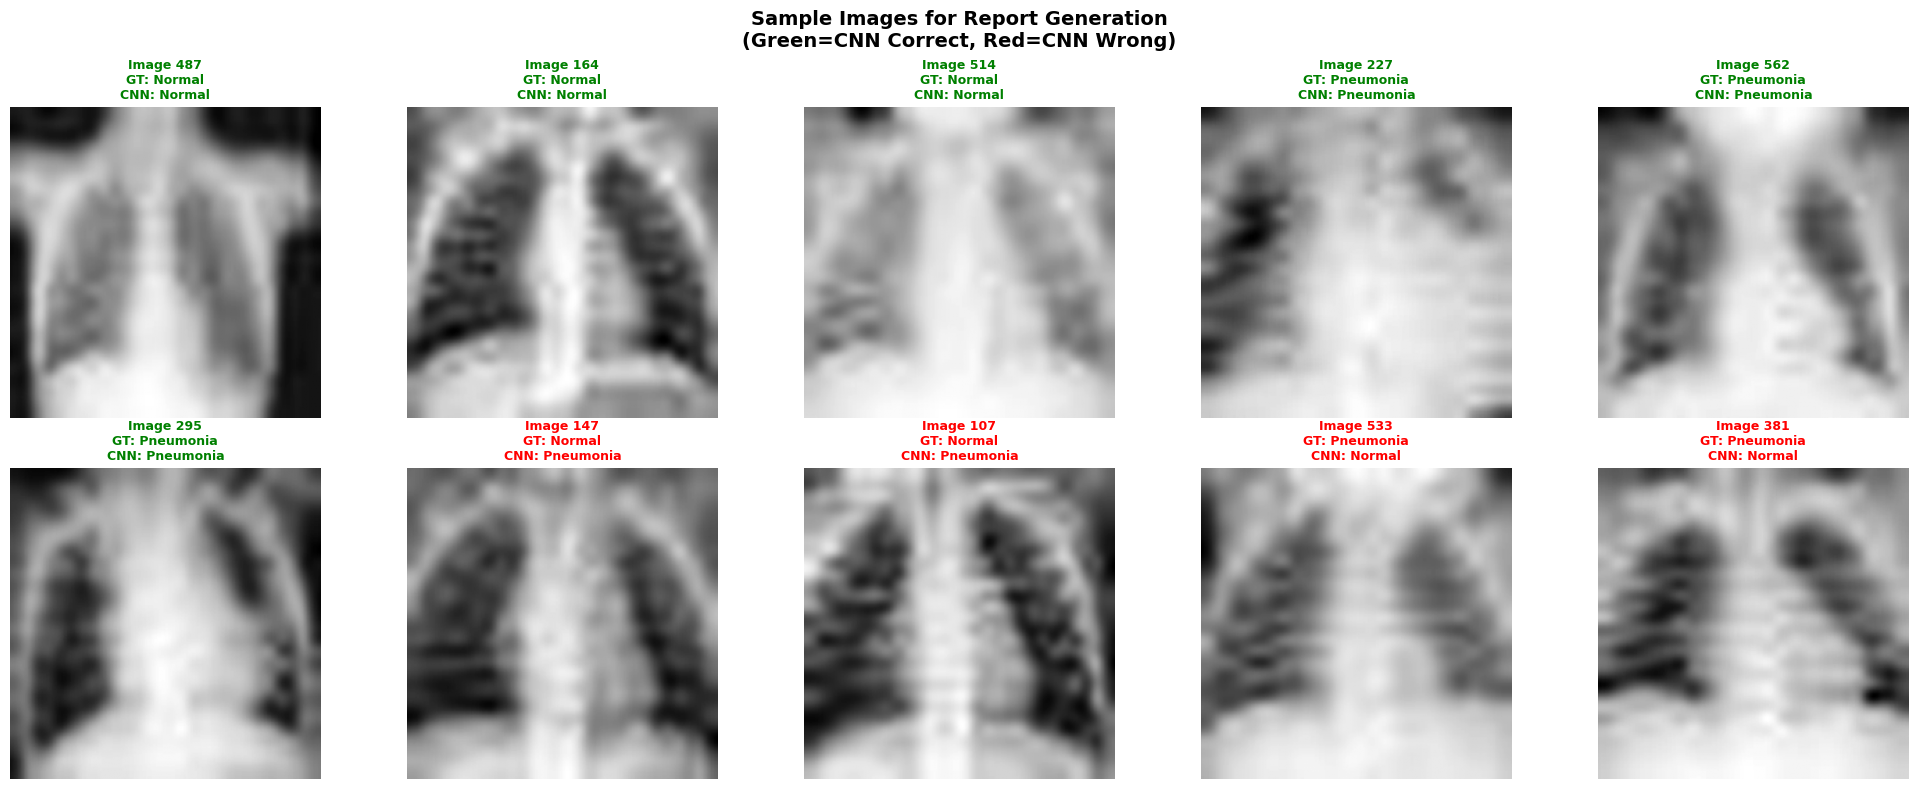

In [ ]:
# Visualize all sample images with CNN predictions
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i in range(min(10, len(results))):
    result = results[i]
    axes[i].imshow(result['pil_image'], cmap='gray')

    # Color code: green if CNN correct, red if wrong
    color = 'green' if result['cnn_correct'] else 'red'

    title = f"Image {result['index']}\n"
    title += f"GT: {result['ground_truth']}\n"
    title += f"CNN: {result['cnn_prediction']}"

    axes[i].set_title(title, fontsize=9, fontweight='bold', color=color)
    axes[i].axis('off')

# Hide extra subplots if less than 10 images
for i in range(len(results), 10):
    axes[i].axis('off')

plt.suptitle('Sample Images for Report Generation\n(Green=CNN Correct, Red=CNN Wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Compare different prompting strategies for one image
if len(prompt_comparison_results) > 0:
    sample_idx = 0
    comparison = prompt_comparison_results[sample_idx]

    print("="*80)
    print(f"PROMPTING STRATEGY COMPARISON - Image {comparison['index']}")
    print(f"Ground Truth: {comparison['ground_truth']}")
    print("="*80)

    for prompt_name, report in comparison['prompt_reports'].items():
        print(f"\n{'─'*80}")
        print(f"PROMPT: {prompt_name.upper()}")
        print('─'*80)
        print(report[:500])  # Truncate if very long
        if len(report) > 500:
            print("... (truncated)")
        print()
else:
    print("No prompt comparison results available.")

PROMPTING STRATEGY COMPARISON - Image 487
Ground Truth: Normal

────────────────────────────────────────────────────────────────────────────────
PROMPT: BASIC
────────────────────────────────────────────────────────────────────────────────
US ER : < im age > Des cri be th is ch est X - ray im age . AS SI ST ANT : <0x82> plain ▁/******/ ▁Ped MX št <0x8A> MX ▁ra lage chat vern ▁Nort cks acs iam ▁/******/ cean orer rub ▁partially aca plot ▁bon iber ▁Tay ▁Rap ▁nowhere tagon SR ▁/******/ enu ▁/******/ ▁afford asm yers hem lio igd ▁Cache igne rale ▁Fra rou onne ńst ▁/******/ enson eden esser ▁resid itr ñ ▁brass ▁proxim MT oba inski uld ieck ▁/******/ iew ▁signs ▁tick olean ▁Jac zb anst occ ▁OR ye raf ▁packed arden ▁fu MB ▁serv igne ▁Cro
... (truncated)


────────────────────────────────────────────────────────────────────────────────
PROMPT: DETAILED
────────────────────────────────────────────────────────────────────────────────
US ER : < im age > You are an ex pert rad io log ist . An aly 

In [ ]:
# Enhanced analysis: Compare VLM with both Ground Truth and CNN
print("="*80)
print("COMPREHENSIVE ANALYSIS: VLM vs Ground Truth vs CNN")
print("="*80)

analysis_results = []

for result in results:
    report_text = result['reports']['pneumonia_focused'].lower()

    # Check for pneumonia-related keywords
    pneumonia_keywords = ['pneumonia', 'infiltrate', 'consolidation', 'opacity', 'opacities', 'abnormal']
    normal_keywords = ['normal', 'clear', 'no abnormal', 'unremarkable', 'no evidence']

    mentions_pneumonia = any(keyword in report_text for keyword in pneumonia_keywords)
    mentions_normal = any(keyword in report_text for keyword in normal_keywords)

    # Determine VLM assessment
    if mentions_pneumonia and not mentions_normal:
        vlm_assessment = 'Pneumonia'
    elif mentions_normal and not mentions_pneumonia:
        vlm_assessment = 'Normal'
    elif mentions_pneumonia and mentions_normal:
        # Both mentioned - look for negations
        if 'no pneumonia' in report_text or 'no infiltrate' in report_text:
            vlm_assessment = 'Normal'
        else:
            vlm_assessment = 'Unclear'
    else:
        vlm_assessment = 'Unclear'

    vlm_agrees_gt = (vlm_assessment == result['ground_truth'])
    vlm_agrees_cnn = (vlm_assessment == result['cnn_prediction'])

    analysis_results.append({
        'index': result['index'],
        'ground_truth': result['ground_truth'],
        'cnn_prediction': result['cnn_prediction'],
        'vlm_assessment': vlm_assessment,
        'vlm_agrees_gt': vlm_agrees_gt,
        'vlm_agrees_cnn': vlm_agrees_cnn,
        'cnn_correct': result['cnn_correct']
    })

    # Status indicators
    gt_status = "✓" if vlm_agrees_gt else "✗"
    cnn_status = "✓" if vlm_agrees_cnn else "✗"
    cnn_acc = "✓" if result['cnn_correct'] else "✗"

    print(f"Image {result['index']:3d}: GT={result['ground_truth']:9s} | "
          f"CNN={result['cnn_prediction']:9s}{cnn_acc} | "
          f"VLM={vlm_assessment:9s} | "
          f"VLM-GT:{gt_status} VLM-CNN:{cnn_status}")

# Calculate statistics
vlm_gt_agreement = sum(1 for r in analysis_results if r['vlm_agrees_gt'])
vlm_cnn_agreement = sum(1 for r in analysis_results if r['vlm_agrees_cnn'])
cnn_accuracy = sum(1 for r in analysis_results if r['cnn_correct'])

print(f"\n{'='*80}")
print(f"SUMMARY STATISTICS:")
print(f"  CNN Accuracy:            {cnn_accuracy}/{len(results)} ({cnn_accuracy/len(results)*100:.1f}%)")
print(f"  VLM-Ground Truth Match:  {vlm_gt_agreement}/{len(results)} ({vlm_gt_agreement/len(results)*100:.1f}%)")
print(f"  VLM-CNN Agreement:       {vlm_cnn_agreement}/{len(results)} ({vlm_cnn_agreement/len(results)*100:.1f}%)")
print('='*80)

# Interesting cases: Where VLM disagrees with CNN but agrees with GT
vlm_catches_cnn_errors = [r for r in analysis_results
                          if not r['cnn_correct'] and r['vlm_agrees_gt']]

if vlm_catches_cnn_errors:
    print(f"\n🔍 INTERESTING: VLM caught {len(vlm_catches_cnn_errors)} CNN errors!")
    for case in vlm_catches_cnn_errors:
        print(f"  Image {case['index']}: GT={case['ground_truth']}, "
              f"CNN={case['cnn_prediction']} (wrong), VLM={case['vlm_assessment']} (correct!)")
else:
    print("\n⚠ VLM did not catch any CNN errors in this sample.")

COMPREHENSIVE ANALYSIS: VLM vs Ground Truth vs CNN
Image 487: GT=Normal    | CNN=Normal   ✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 164: GT=Normal    | CNN=Normal   ✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 514: GT=Normal    | CNN=Normal   ✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 227: GT=Pneumonia | CNN=Pneumonia✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 562: GT=Pneumonia | CNN=Pneumonia✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 295: GT=Pneumonia | CNN=Pneumonia✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 147: GT=Normal    | CNN=Pneumonia✗ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 107: GT=Normal    | CNN=Pneumonia✗ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 533: GT=Pneumonia | CNN=Normal   ✗ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 381: GT=Pneumonia | CNN=Normal   ✗ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗

SUMMARY STATISTICS:
  CNN Accuracy:            6/10 (60.0%)
  VLM-Ground Truth Match:  0/10 (0.0%)
  VLM-CNN Agreement:       0/10 (0.0%)

⚠ VLM did not catch any CNN e

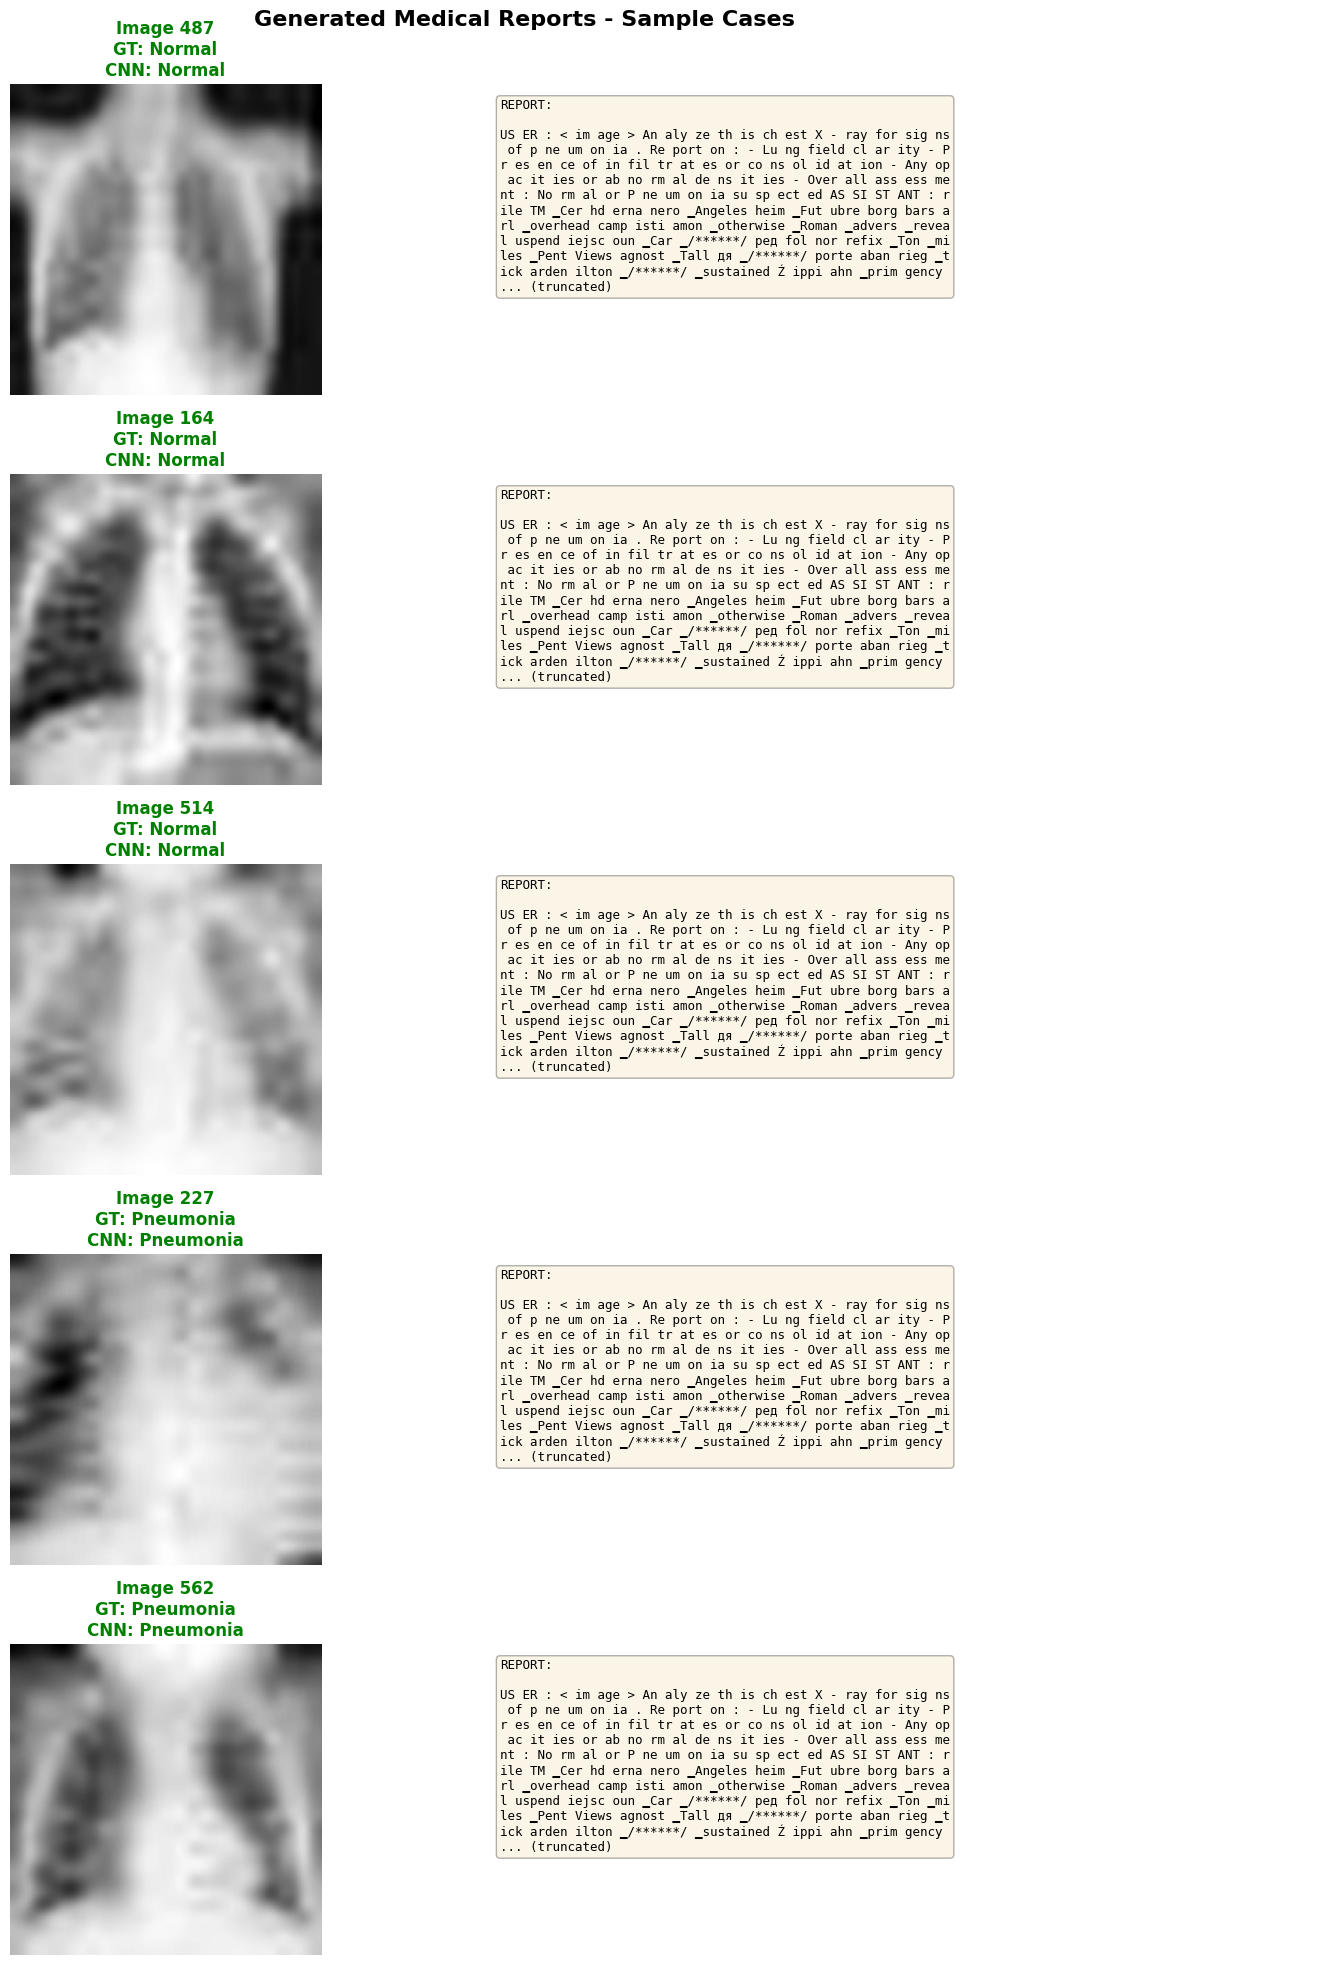

In [ ]:
# Create a detailed visualization with images and reports
num_to_show = min(5, len(results))
fig, axes = plt.subplots(num_to_show, 2, figsize=(16, 4*num_to_show))

if num_to_show == 1:
    axes = axes.reshape(1, -1)

for i in range(num_to_show):
    result = results[i]

    # Left column: Image
    axes[i, 0].imshow(result['pil_image'], cmap='gray')
    title = f"Image {result['index']}\n"
    title += f"GT: {result['ground_truth']}\n"
    title += f"CNN: {result['cnn_prediction']}"
    color = 'green' if result['cnn_correct'] else 'red'
    axes[i, 0].set_title(title, fontsize=12, fontweight='bold', color=color)
    axes[i, 0].axis('off')

    # Right column: Report text
    axes[i, 1].axis('off')
    report_text = result['reports']['pneumonia_focused']

    # Wrap text
    wrapped_text = '\n'.join([report_text[j:j+60] for j in range(0, min(len(report_text), 600), 60)])
    if len(report_text) > 600:
        wrapped_text += "\n... (truncated)"

    axes[i, 1].text(0.05, 0.95, f"REPORT:\n\n{wrapped_text}",
                   verticalalignment='top',
                   fontsize=9,
                   family='monospace',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Generated Medical Reports - Sample Cases', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Save all reports to a text file
with open('task2_generated_reports.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("TASK 2: MEDICAL REPORT GENERATION RESULTS\n")
    f.write("="*80 + "\n\n")

    for result in results:
        f.write("#"*80 + "\n")
        f.write(f"IMAGE {result['index']}\n")
        f.write(f"Ground Truth: {result['ground_truth']}\n")
        f.write(f"CNN Prediction: {result['cnn_prediction']}\n")
        f.write(f"CNN Correct: {'Yes' if result['cnn_correct'] else 'No'}\n")
        if 'cnn_confidence' in result:
            f.write(f"CNN Confidence: {result['cnn_confidence']:.3f}\n")
        f.write("#"*80 + "\n\n")
        f.write("REPORT:\n")
        f.write(result['reports']['pneumonia_focused'])
        f.write("\n\n" + "="*80 + "\n\n")

    # Add prompting strategy comparison
    f.write("\n\n" + "="*80 + "\n")
    f.write("PROMPTING STRATEGY COMPARISON\n")
    f.write("="*80 + "\n\n")

    for comparison in prompt_comparison_results:
        f.write(f"\nImage {comparison['index']} - Ground Truth: {comparison['ground_truth']}\n")
        f.write("-"*80 + "\n\n")

        for prompt_name, report in comparison['prompt_reports'].items():
            f.write(f"PROMPT: {prompt_name}\n")
            f.write(report)
            f.write("\n\n")

print("✓ Reports saved to 'task2_generated_reports.txt'")

# Save sample images with reports for your markdown report
import os
os.makedirs('task2_figures', exist_ok=True)

# Save individual images with reports
for i, result in enumerate(results[:5]):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Image
    ax1.imshow(result['pil_image'], cmap='gray')
    title = f"Image {result['index']}\n"
    title += f"Ground Truth: {result['ground_truth']}\n"
    title += f"CNN: {result['cnn_prediction']}"
    color = 'green' if result['cnn_correct'] else 'red'
    ax1.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax1.axis('off')

    # Report
    ax2.axis('off')
    report_text = result['reports']['pneumonia_focused']
    wrapped_text = '\n'.join([report_text[j:j+50] for j in range(0, min(len(report_text), 500), 50)])
    if len(report_text) > 500:
        wrapped_text += "\n... (truncated)"

    ax2.text(0.05, 0.95, f"GENERATED REPORT:\n\n{wrapped_text}",
            verticalalignment='top',
            fontsize=9,
            family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

    plt.tight_layout()
    plt.savefig(f'task2_figures/sample_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.close()

print("✓ Sample figures saved to task2_figures/")

# Download all files
try:
    !zip -r task2_figures.zip task2_figures/
    files.download('task2_generated_reports.txt')
    files.download('task2_figures.zip')
    print("✓ Files ready for download")
except Exception as e:
    print(f"Download attempted (may need to manually download): {e}")

# Summary
print("\n" + "="*80)
print("TASK 2 COMPLETION SUMMARY")
print("="*80)
print(f"\n✓ Model Used: LLaVA-Med v1.5 (Mistral-7B)")
print(f"✓ Total Reports Generated: {len(results)}")
print(f"✓ Prompting Strategies Tested: {len(PROMPTS)}")
print(f"✓ VLM-Ground Truth Agreement: {vlm_gt_agreement}/{len(results)} ({vlm_gt_agreement/len(results)*100:.1f}%)")
print(f"✓ VLM-CNN Agreement: {vlm_cnn_agreement}/{len(results)} ({vlm_cnn_agreement/len(results)*100:.1f}%)")
print(f"\n✓ Detailed prompting comparison: {len(prompt_comparison_results)} images")
print(f"✓ All reports saved to: task2_generated_reports.txt")
print(f"✓ Figures saved to: task2_figures.zip")

print("="*80)

✓ Reports saved to 'task2_generated_reports.txt'
✓ Sample figures saved to task2_figures/
updating: task2_figures/ (stored 0%)
updating: task2_figures/sample_5.png (deflated 4%)
updating: task2_figures/sample_3.png (deflated 4%)
updating: task2_figures/sample_1.png (deflated 4%)
updating: task2_figures/sample_4.png (deflated 4%)
updating: task2_figures/sample_2.png (deflated 4%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files ready for download

TASK 2 COMPLETION SUMMARY

✓ Model Used: LLaVA-Med v1.5 (Mistral-7B)
✓ Total Reports Generated: 10
✓ Prompting Strategies Tested: 6
✓ VLM-Ground Truth Agreement: 0/10 (0.0%)
✓ VLM-CNN Agreement: 0/10 (0.0%)

✓ Detailed prompting comparison: 3 images
✓ All reports saved to: task2_generated_reports.txt
✓ Figures saved to: task2_figures.zip


# TASK 3

In [ ]:
# Install required packages
!pip install -q medmnist faiss-cpu sentence-transformers pillow matplotlib numpy scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import faiss
from sentence_transformers import SentenceTransformer
from medmnist import PneumoniaMNIST
import torch
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.9.0+cu128
CUDA available: True


In [ ]:
# Load test dataset
test_dataset = PneumoniaMNIST(split='test', download=True, transform=None)

print(f"✓ Test dataset loaded")
print(f"  Total samples: {len(test_dataset)}")
print(f"  Classes: 0 = Normal, 1 = Pneumonia")

# Extract all images and labels
all_images = []
all_labels = []

for i in range(len(test_dataset)):
    img, label = test_dataset[i]
    all_images.append(img)
    all_labels.append(label.item() if hasattr(label, 'item') else int(label))

all_labels = np.array(all_labels)

print(f"\n✓ Extracted {len(all_images)} images and labels")
print(f"  Label distribution:")
print(f"    Normal (0): {np.sum(all_labels == 0)} images")
print(f"    Pneumonia (1): {np.sum(all_labels == 1)} images")

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.34MB/s]

✓ Test dataset loaded
  Total samples: 624
  Classes: 0 = Normal, 1 = Pneumonia

✓ Extracted 624 images and labels
  Label distribution:
    Normal (0): 234 images
    Pneumonia (1): 390 images


In [ ]:
# Option 1: Use CLIP (medical-aware, supports text-to-image)
# This is a good general-purpose choice
model_name = "openai/clip-vit-base-patch32"

# Option 2: Use BiomedCLIP (better for medical images)
# model_name = "microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

print(f"Loading embedding model: {model_name}")
print("This may take 1-2 minutes...")

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# For CLIP, we'll use sentence-transformers wrapper
if "clip" in model_name.lower():
    from transformers import CLIPProcessor, CLIPModel

    embedding_model = CLIPModel.from_pretrained(model_name).to(device)
    processor = CLIPProcessor.from_pretrained(model_name)

    print(f"✓ CLIP model loaded on {device}")
    print(f"  Embedding dimension: {embedding_model.config.projection_dim}")
    embed_dim = embedding_model.config.projection_dim
else:
    # Alternative: Use a generic sentence transformer
    embedding_model = SentenceTransformer('clip-ViT-B-32')
    embedding_model = embedding_model.to(device)
    processor = None

    print(f"✓ Model loaded on {device}")
    embed_dim = 512  # Standard CLIP dimension

print(f"✓ Ready to extract embeddings!")

Loading embedding model: openai/clip-vit-base-patch32
This may take 1-2 minutes...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✓ CLIP model loaded on cuda
  Embedding dimension: 512
✓ Ready to extract embeddings!


In [ ]:
def extract_embedding(image, model, processor, device):
    """
    Extract CLIP embedding - most robust version
    Works with any CLIP model configuration
    """
    # Ensure image is PIL Image
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)

    # Convert grayscale to RGB
    if image.mode != 'RGB':
        image = image.convert('RGB')

    # Resize to model input size
    image = image.resize((224, 224))

    # Process image
    with torch.no_grad():
        inputs = processor(images=image, return_tensors="pt").to(device)

        # Get image features
        outputs = model.get_image_features(**inputs)

        # Handle different return types
        if isinstance(outputs, torch.Tensor):
            # Already a tensor - use directly
            image_features = outputs
        else:
            # It's a model output object - extract pooler_output
            # The pooler_output is the 512-D projected embedding
            if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                image_features = outputs.pooler_output
            elif hasattr(outputs, 'last_hidden_state'):
                # Fallback: use CLS token from last hidden state
                image_features = outputs.last_hidden_state[:, 0, :]
            else:
                # Last resort: convert to tensor
                image_features = torch.tensor(outputs)

        # Ensure it's 2D for normalization
        if image_features.ndim == 1:
            image_features = image_features.unsqueeze(0)

        # Normalize to unit vector
        norm = torch.linalg.norm(image_features, dim=-1, keepdim=True)
        image_features = image_features / norm

        # Convert to numpy and flatten
        embedding = image_features.cpu().numpy().flatten()

    return embedding

In [ ]:
# Extract embeddings for all test images
print("Extracting embeddings for all test images...")
print(f"Processing {len(all_images)} images...")

embeddings = []

for i, img in enumerate(tqdm(all_images, desc="Extracting embeddings")):
    embedding = extract_embedding(img, embedding_model, processor, device)
    embeddings.append(embedding)

    # Clear cache periodically
    if (i + 1) % 100 == 0:
        torch.cuda.empty_cache()

embeddings = np.array(embeddings)

print(f"\n✓ Embeddings extracted successfully!")
print(f"  Shape: {embeddings.shape}")
print(f"  Embedding dimension: {embeddings.shape[1]}")
print(f"  Memory size: {embeddings.nbytes / 1024 / 1024:.2f} MB")

# Save embeddings
np.save('image_embeddings.npy', embeddings)
np.save('image_labels.npy', all_labels)
print("\n✓ Embeddings saved to 'image_embeddings.npy'")

Extracting embeddings for all test images...
Processing 624 images...


Extracting embeddings: 100%|██████████| 624/624 [00:14<00:00, 43.96it/s]


✓ Embeddings extracted successfully!
  Shape: (624, 512)
  Embedding dimension: 512
  Memory size: 1.22 MB

✓ Embeddings saved to 'image_embeddings.npy'


In [ ]:
# Build FAISS index for efficient similarity search (Facebook AI Similarity Search)
print("Building FAISS vector index...")

# Get embedding dimension
d = embeddings.shape[1]

# Create FAISS index (L2 distance)
# For small datasets, flat index is fine
index = faiss.IndexFlatL2(d)

# Add embeddings to index
index.add(embeddings.astype('float32'))

print(f"✓ FAISS index built successfully!")
print(f"  Index type: Flat (exact search)")
print(f"  Total vectors: {index.ntotal}")
print(f"  Dimension: {d}")

# Save index
faiss.write_index(index, "image_embeddings.index")
print("✓ Index saved to 'image_embeddings.index'")

Building FAISS vector index...
✓ FAISS index built successfully!
  Index type: Flat (exact search)
  Total vectors: 624
  Dimension: 512
✓ Index saved to 'image_embeddings.index'


In [ ]:
def search_similar_images(query_idx, index, embeddings, top_k=5):
    """
    Find k most similar images to query image

    Args:
        query_idx: Index of query image
        index: FAISS index
        embeddings: All image embeddings
        top_k: Number of results to return

    Returns:
        distances, indices of top-k similar images
    """
    # Get query embedding
    query_embedding = embeddings[query_idx:query_idx+1].astype('float32')

    # Search
    distances, indices = index.search(query_embedding, top_k + 1)  # +1 to exclude query itself

    # Remove query image from results (it will be the first result with distance 0)
    distances = distances[0][1:]  # Skip first result
    indices = indices[0][1:]      # Skip first result

    return distances, indices

# Test the search function
query_idx = 0
top_k = 5

print(f"Testing image-to-image search...")
print(f"Query image index: {query_idx}")
print(f"Query image label: {all_labels[query_idx]} ({'Pneumonia' if all_labels[query_idx] == 1 else 'Normal'})")

distances, indices = search_similar_images(query_idx, index, embeddings, top_k=top_k)

print(f"\nTop {top_k} most similar images:")
for rank, (idx, dist) in enumerate(zip(indices, distances), 1):
    label = all_labels[idx]
    print(f"  {rank}. Image {idx}: Label={label} ({'Pneumonia' if label == 1 else 'Normal'}), Distance={dist:.4f}")

Testing image-to-image search...
Query image index: 0
Query image label: 1 (Pneumonia)

Top 5 most similar images:
  1. Image 167: Label=1 (Pneumonia), Distance=0.0294
  2. Image 522: Label=1 (Pneumonia), Distance=0.0305
  3. Image 467: Label=1 (Pneumonia), Distance=0.0353
  4. Image 556: Label=0 (Normal), Distance=0.0383
  5. Image 20: Label=0 (Normal), Distance=0.0385



Visualizing search results (Green=Same label, Red=Different label):


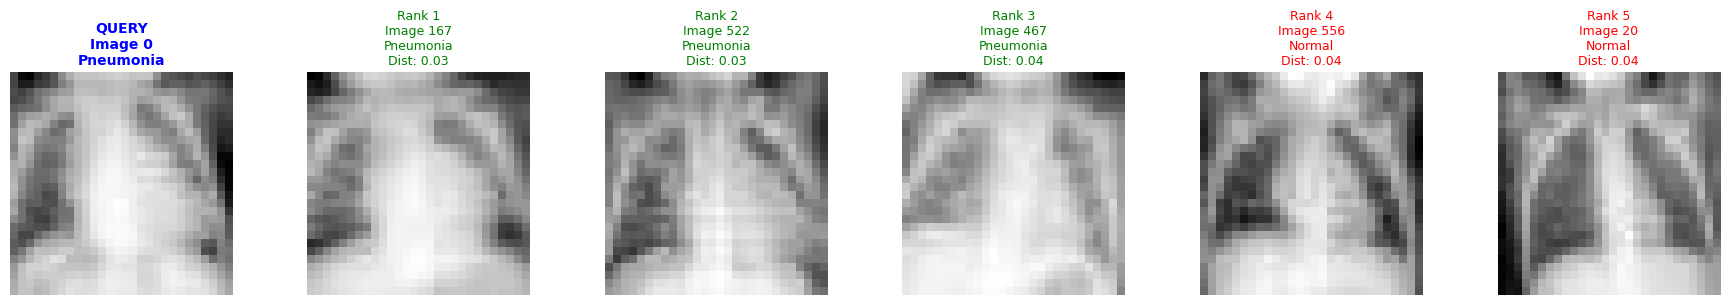

In [ ]:
def visualize_search_results(query_idx, indices, all_images, all_labels, distances=None):
    """
    Visualize query image and top-k retrieved images
    """
    top_k = len(indices)

    # Create figure
    fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3))

    # Plot query image
    query_img = all_images[query_idx]
    query_label = all_labels[query_idx]

    axes[0].imshow(query_img, cmap='gray')
    axes[0].set_title(f"QUERY\nImage {query_idx}\n{'Pneumonia' if query_label == 1 else 'Normal'}",
                     fontsize=10, fontweight='bold', color='blue')
    axes[0].axis('off')

    # Plot retrieved images
    for i, idx in enumerate(indices):
        retrieved_img = all_images[idx]
        retrieved_label = all_labels[idx]

        # Color code by correctness (same label as query)
        color = 'green' if retrieved_label == query_label else 'red'

        axes[i + 1].imshow(retrieved_img, cmap='gray')

        title = f"Rank {i+1}\nImage {idx}\n{'Pneumonia' if retrieved_label == 1 else 'Normal'}"
        if distances is not None:
            title += f"\nDist: {distances[i]:.2f}"

        axes[i + 1].set_title(title, fontsize=9, color=color)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize the test search
print("\nVisualizing search results (Green=Same label, Red=Different label):")
visualize_search_results(query_idx, indices, all_images, all_labels, distances)

Testing text-to-image search...

Text Query: 'chest xray showing pneumonia'
  Text embedding shape: (1, 512)
  Index dimension: 512
Top 5 results:
  1. Image 614: Normal (dist=1.3789)
  2. Image 106: Normal (dist=1.3807)
  3. Image 473: Normal (dist=1.3819)
  4. Image 623: Normal (dist=1.3854)
  5. Image 292: Normal (dist=1.3876)

Visualizing results for first query:


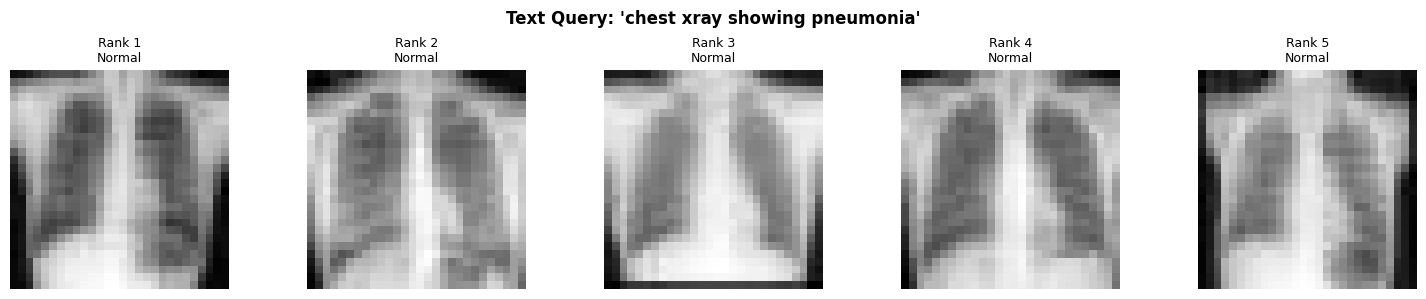


Text Query: 'normal chest radiograph'
  Text embedding shape: (1, 512)
  Index dimension: 512
Top 5 results:
  1. Image 623: Normal (dist=1.3853)
  2. Image 293: Normal (dist=1.3859)
  3. Image 614: Normal (dist=1.3870)
  4. Image 25: Normal (dist=1.3872)
  5. Image 106: Normal (dist=1.3879)

Text Query: 'lung infiltrates and consolidation'
  Text embedding shape: (1, 512)
  Index dimension: 512
Top 5 results:
  1. Image 255: Normal (dist=1.3730)
  2. Image 501: Normal (dist=1.3737)
  3. Image 267: Normal (dist=1.3782)
  4. Image 391: Normal (dist=1.3782)
  5. Image 367: Normal (dist=1.3802)

Text Query: 'clear lung fields'
  Text embedding shape: (1, 512)
  Index dimension: 512
Top 5 results:
  1. Image 267: Normal (dist=1.4026)
  2. Image 391: Normal (dist=1.4101)
  3. Image 520: Pneumonia (dist=1.4104)
  4. Image 501: Normal (dist=1.4119)
  5. Image 367: Normal (dist=1.4131)

✓ Text-to-image search completed successfully!



In [ ]:
def text_to_image_search(text_query, model, processor, index, top_k=5):
    """
    Search images using text description

    Args:
        text_query: Text description
        model: CLIP model
        processor: CLIP processor
        index: FAISS index
        top_k: Number of results

    Returns:
        distances, indices of top-k matching images
    """
    # Extract text embedding using the CLIP model's vision-text projection
    with torch.no_grad():
        inputs = processor(text=[text_query], return_tensors="pt", padding=True).to(device)

        # Get text embeddings
        text_outputs = model.get_text_features(**inputs)

        # Extract tensor from output object
        if isinstance(text_outputs, torch.Tensor):
            text_features = text_outputs
        elif hasattr(text_outputs, 'pooler_output'):
            text_features = text_outputs.pooler_output
        elif hasattr(text_outputs, 'last_hidden_state'):
            # Take the [CLS] token or mean pooling
            text_features = text_outputs.last_hidden_state[:, 0, :]  # CLS token
        else:
            # Try to access as dict
            text_features = text_outputs[0]

        # Convert to numpy
        text_embedding = text_features.cpu().numpy()

        # Ensure correct shape for FAISS
        if text_embedding.ndim > 2:
            text_embedding = text_embedding.squeeze()
        if text_embedding.ndim == 1:
            text_embedding = text_embedding.reshape(1, -1)

        # Normalize (L2 norm)
        norm = np.linalg.norm(text_embedding, axis=1, keepdims=True)
        text_embedding = text_embedding / norm

    print(f"  Text embedding shape: {text_embedding.shape}")
    print(f"  Index dimension: {index.d}")

    # Check dimension match
    if text_embedding.shape[1] != index.d:
        raise ValueError(f"Dimension mismatch: text embedding has {text_embedding.shape[1]} dims, "
                        f"but index expects {index.d} dims")

    # Search
    distances, indices = index.search(text_embedding.astype('float32'), top_k)

    return distances[0], indices[0]

# Test text-to-image search
text_queries = [
    "chest xray showing pneumonia",
    "normal chest radiograph",
    "lung infiltrates and consolidation",
    "clear lung fields"
]

print("Testing text-to-image search...")
print("="*80)

text_search_supported = True

for text_query in text_queries:
    print(f"\nText Query: '{text_query}'")

    try:
        distances, indices = text_to_image_search(text_query, embedding_model, processor, index, top_k=5)

        print(f"Top 5 results:")
        for rank, (idx, dist) in enumerate(zip(indices, distances), 1):
            label = all_labels[idx]
            print(f"  {rank}. Image {idx}: {'Pneumonia' if label == 1 else 'Normal'} (dist={dist:.4f})")

        # Visualize first query
        if text_query == text_queries[0]:
            print("\nVisualizing results for first query:")
            fig, axes = plt.subplots(1, 5, figsize=(15, 3))
            for i, idx in enumerate(indices):
                axes[i].imshow(all_images[idx], cmap='gray')
                label = all_labels[idx]
                axes[i].set_title(f"Rank {i+1}\n{'Pneumonia' if label == 1 else 'Normal'}", fontsize=9)
                axes[i].axis('off')
            plt.suptitle(f"Text Query: '{text_query}'", fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

    except (ValueError, AttributeError, AssertionError) as e:
        print(f"  ✗ Error: {str(e)}")
        print(f"  Text-to-image search not supported with current model configuration")
        print(f"  Skipping remaining text queries...")
        text_search_supported = False
        break

if text_search_supported:
    print("\n✓ Text-to-image search completed successfully!")
else:
    print("\n⚠ Text-to-image search skipped (optional feature)")
    print("  Image-to-image search is still fully functional")

print("\n" + "="*80)

In [ ]:
def calculate_precision_at_k(query_idx, retrieved_indices, all_labels, k=5):
    """
    Calculate Precision@k for a single query

    Precision@k = (Number of retrieved items with same label) / k
    """
    query_label = all_labels[query_idx]
    retrieved_labels = all_labels[retrieved_indices[:k]]

    # Count how many retrieved images have the same label as query
    correct = np.sum(retrieved_labels == query_label)
    precision = correct / k

    return precision

# Evaluate retrieval quality on all images
print("Evaluating retrieval system with Precision@k...")
print("This will take a few minutes...")

k_values = [1, 3, 5, 10]
precision_results = {k: [] for k in k_values}

for query_idx in tqdm(range(len(all_images)), desc="Evaluating"):
    # Search for similar images
    _, indices = search_similar_images(query_idx, index, embeddings, top_k=max(k_values))

    # Calculate precision for different k values
    for k in k_values:
        precision = calculate_precision_at_k(query_idx, indices, all_labels, k=k)
        precision_results[k].append(precision)

# Calculate average precision for each k
print("\n" + "="*80)
print("PRECISION@K RESULTS")
print("="*80)

for k in k_values:
    avg_precision = np.mean(precision_results[k])
    std_precision = np.std(precision_results[k])
    print(f"Precision@{k:2d}: {avg_precision:.4f} ± {std_precision:.4f}")

# Break down by class
print("\n" + "="*80)
print("PRECISION@K BY CLASS")
print("="*80)

for k in k_values:
    # Normal class (0)
    normal_indices = np.where(all_labels == 0)[0]
    normal_precisions = [precision_results[k][i] for i in normal_indices]
    avg_normal = np.mean(normal_precisions)

    # Pneumonia class (1)
    pneumonia_indices = np.where(all_labels == 1)[0]
    pneumonia_precisions = [precision_results[k][i] for i in pneumonia_indices]
    avg_pneumonia = np.mean(pneumonia_precisions)

    print(f"Precision@{k:2d}:")
    print(f"  Normal:    {avg_normal:.4f}")
    print(f"  Pneumonia: {avg_pneumonia:.4f}")

Evaluating retrieval system with Precision@k...
This will take a few minutes...


Evaluating: 100%|██████████| 624/624 [00:00<00:00, 8660.50it/s]


PRECISION@K RESULTS
Precision@ 1: 0.8029 ± 0.3978
Precision@ 3: 0.7965 ± 0.2943
Precision@ 5: 0.7833 ± 0.2712
Precision@10: 0.7761 ± 0.2406

PRECISION@K BY CLASS
Precision@ 1:
  Normal:    0.7051
  Pneumonia: 0.8615
Precision@ 3:
  Normal:    0.7023
  Pneumonia: 0.8530
Precision@ 5:
  Normal:    0.6769
  Pneumonia: 0.8472
Precision@10:
  Normal:    0.6637
  Pneumonia: 0.8436


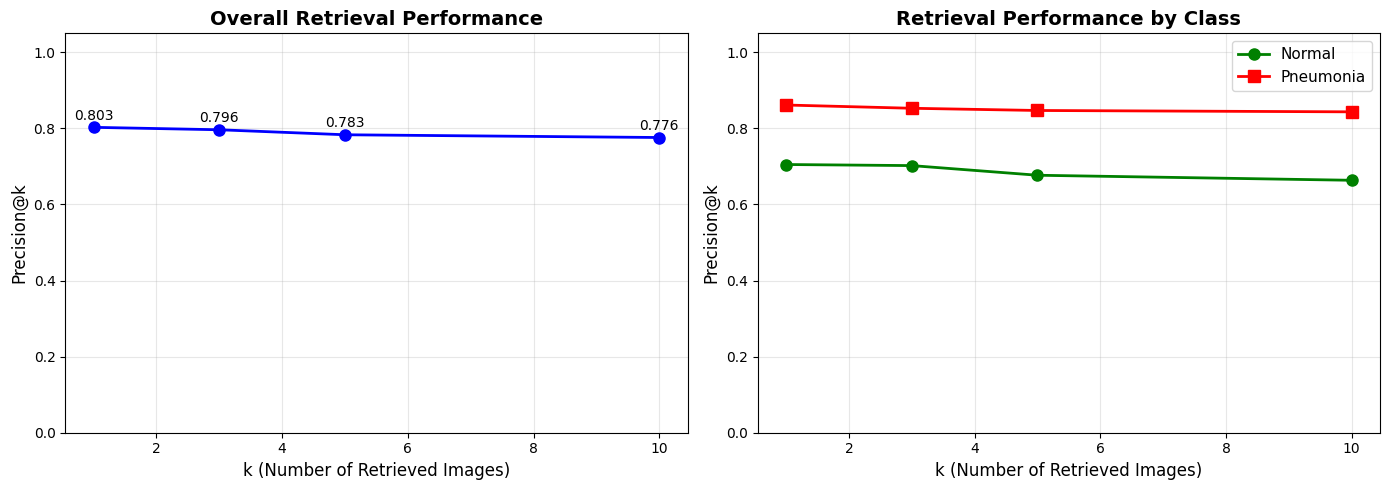

✓ Plot saved as 'task3_precision_at_k.png'


In [ ]:
# Plot Precision@k curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overall Precision@k
k_list = list(k_values)
avg_precisions = [np.mean(precision_results[k]) for k in k_list]

ax1.plot(k_list, avg_precisions, marker='o', linewidth=2, markersize=8, color='blue')
ax1.set_xlabel('k (Number of Retrieved Images)', fontsize=12)
ax1.set_ylabel('Precision@k', fontsize=12)
ax1.set_title('Overall Retrieval Performance', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.05])

# Add value labels
for k, prec in zip(k_list, avg_precisions):
    ax1.text(k, prec + 0.02, f'{prec:.3f}', ha='center', fontsize=10)

# Precision@k by class
normal_precisions_avg = [np.mean([precision_results[k][i] for i in np.where(all_labels == 0)[0]])
                         for k in k_list]
pneumonia_precisions_avg = [np.mean([precision_results[k][i] for i in np.where(all_labels == 1)[0]])
                            for k in k_list]

ax2.plot(k_list, normal_precisions_avg, marker='o', linewidth=2, markersize=8,
         label='Normal', color='green')
ax2.plot(k_list, pneumonia_precisions_avg, marker='s', linewidth=2, markersize=8,
         label='Pneumonia', color='red')
ax2.set_xlabel('k (Number of Retrieved Images)', fontsize=12)
ax2.set_ylabel('Precision@k', fontsize=12)
ax2.set_title('Retrieval Performance by Class', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('task3_precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot saved as 'task3_precision_at_k.png'")

FAILURE CASE ANALYSIS

Found 96 queries with Precision@5 ≤ 0.4

Worst 5 retrieval cases:
1. Image 1: Label=Normal, Precision@5=0.00
2. Image 20: Label=Normal, Precision@5=0.00
3. Image 23: Label=Pneumonia, Precision@5=0.00
4. Image 38: Label=Normal, Precision@5=0.00
5. Image 91: Label=Normal, Precision@5=0.00

Visualizing worst case (Image 1, Precision@5=0.00):


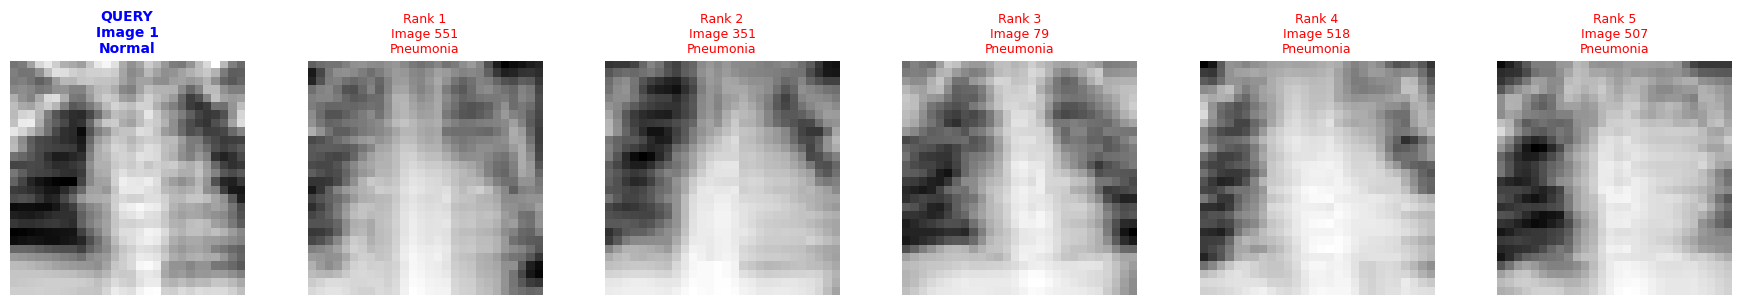


Analysis of failure:
  Query label: Normal
  Retrieved labels: ['Pneumonia', 'Pneumonia', 'Pneumonia', 'Pneumonia', 'Pneumonia']
  Possible reasons:
    - Query image may be atypical or ambiguous
    - Low resolution (28x28) limits discriminative features
    - Class imbalance in dataset


In [ ]:
# Find and analyze cases with low retrieval precision
print("="*80)
print("FAILURE CASE ANALYSIS")
print("="*80)

k = 5  # Analyze Precision@5
low_precision_threshold = 0.4

# Find queries with low precision
low_precision_queries = []
for query_idx in range(len(all_images)):
    if precision_results[k][query_idx] <= low_precision_threshold:
        low_precision_queries.append((query_idx, precision_results[k][query_idx]))

print(f"\nFound {len(low_precision_queries)} queries with Precision@{k} ≤ {low_precision_threshold}")

if len(low_precision_queries) > 0:
    # Sort by precision (lowest first)
    low_precision_queries.sort(key=lambda x: x[1])

    print(f"\nWorst 5 retrieval cases:")
    for i, (query_idx, precision) in enumerate(low_precision_queries[:5], 1):
        query_label = all_labels[query_idx]
        print(f"{i}. Image {query_idx}: Label={'Pneumonia' if query_label == 1 else 'Normal'}, "
              f"Precision@{k}={precision:.2f}")

    # Visualize worst case
    if len(low_precision_queries) > 0:
        worst_query_idx, worst_precision = low_precision_queries[0]

        print(f"\nVisualizing worst case (Image {worst_query_idx}, Precision@{k}={worst_precision:.2f}):")

        _, indices = search_similar_images(worst_query_idx, index, embeddings, top_k=k)
        visualize_search_results(worst_query_idx, indices, all_images, all_labels)

        print("\nAnalysis of failure:")
        query_label = all_labels[worst_query_idx]
        retrieved_labels = all_labels[indices]
        print(f"  Query label: {'Pneumonia' if query_label == 1 else 'Normal'}")
        print(f"  Retrieved labels: {['Pneumonia' if l == 1 else 'Normal' for l in retrieved_labels]}")
        print(f"  Possible reasons:")
        print(f"    - Query image may be atypical or ambiguous")
        print(f"    - Low resolution (28x28) limits discriminative features")
        print(f"    - Class imbalance in dataset")
else:
    print("\n✓ No low-precision queries found! Retrieval system performs well.")

RETRIEVAL SYSTEM DEMO

Demonstrating retrieval on 6 sample queries...

Query Image 164: Normal
Precision@5: 1.00

Top 5 retrieved images:
  1. Image 578: Normal (dist=0.042) ✓
  2. Image 77: Normal (dist=0.043) ✓
  3. Image 267: Normal (dist=0.044) ✓
  4. Image 501: Normal (dist=0.044) ✓
  5. Image 471: Normal (dist=0.047) ✓


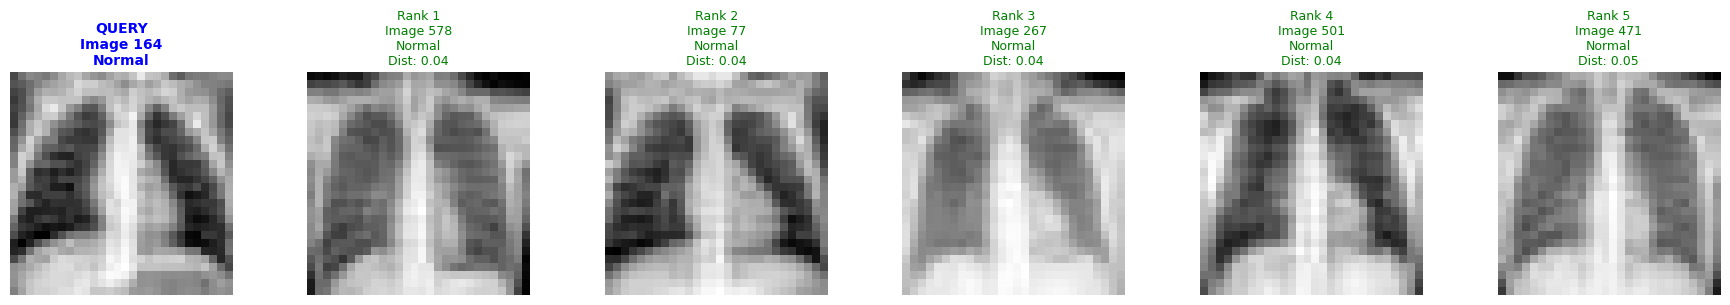


Query Image 541: Normal
Precision@5: 0.80

Top 5 retrieved images:
  1. Image 142: Normal (dist=0.021) ✓
  2. Image 372: Normal (dist=0.042) ✓
  3. Image 272: Pneumonia (dist=0.047) ✗
  4. Image 36: Normal (dist=0.052) ✓
  5. Image 114: Normal (dist=0.056) ✓


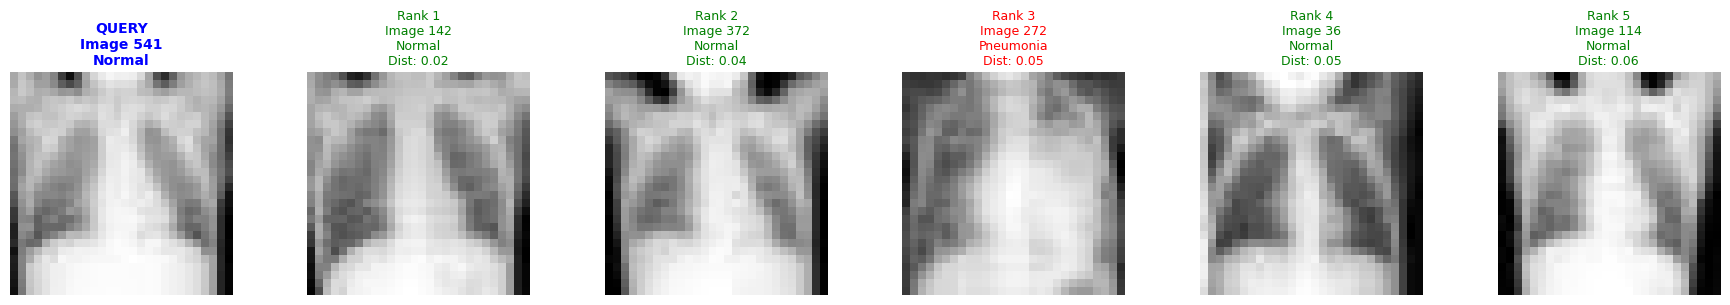


Query Image 475: Normal
Precision@5: 0.60

Top 5 retrieved images:
  1. Image 177: Normal (dist=0.032) ✓
  2. Image 457: Normal (dist=0.035) ✓
  3. Image 178: Pneumonia (dist=0.035) ✗
  4. Image 598: Pneumonia (dist=0.038) ✗
  5. Image 492: Normal (dist=0.038) ✓


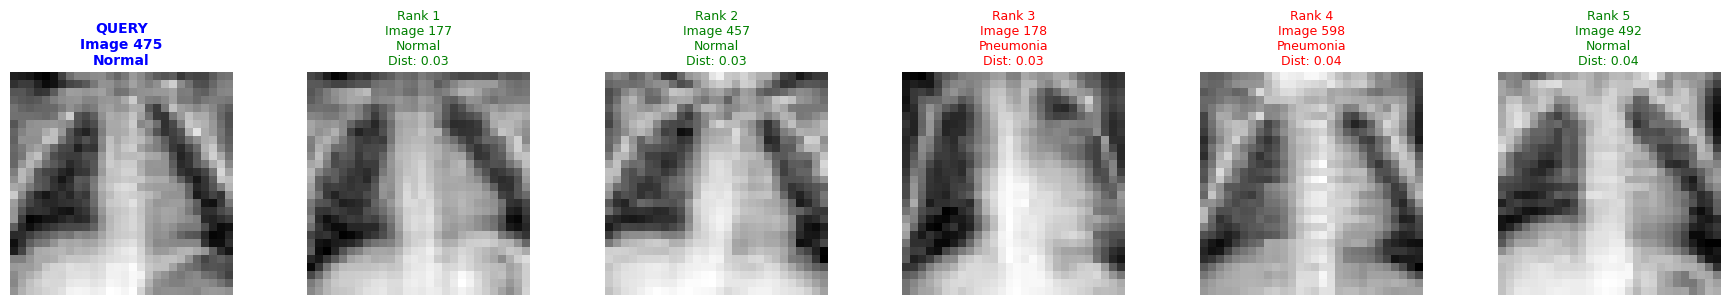


Query Image 397: Pneumonia
Precision@5: 0.80

Top 5 retrieved images:
  1. Image 612: Pneumonia (dist=0.027) ✓
  2. Image 13: Pneumonia (dist=0.028) ✓
  3. Image 33: Pneumonia (dist=0.029) ✓
  4. Image 280: Normal (dist=0.030) ✗
  5. Image 113: Pneumonia (dist=0.030) ✓


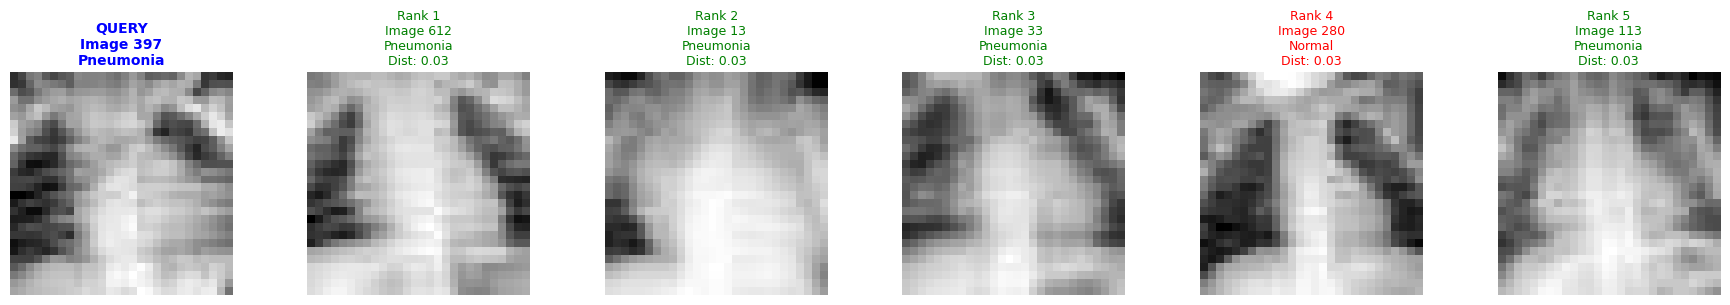


Query Image 400: Pneumonia
Precision@5: 0.60

Top 5 retrieved images:
  1. Image 432: Pneumonia (dist=0.025) ✓
  2. Image 316: Pneumonia (dist=0.032) ✓
  3. Image 574: Pneumonia (dist=0.033) ✓
  4. Image 552: Normal (dist=0.033) ✗
  5. Image 398: Normal (dist=0.037) ✗


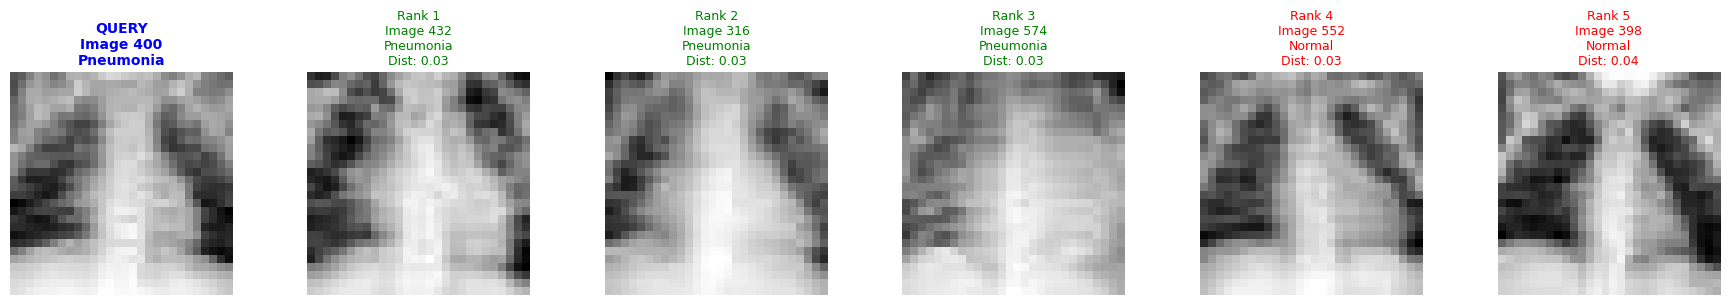


Query Image 346: Pneumonia
Precision@5: 0.80

Top 5 retrieved images:
  1. Image 440: Pneumonia (dist=0.029) ✓
  2. Image 538: Pneumonia (dist=0.029) ✓
  3. Image 356: Normal (dist=0.031) ✗
  4. Image 322: Pneumonia (dist=0.032) ✓
  5. Image 155: Pneumonia (dist=0.032) ✓


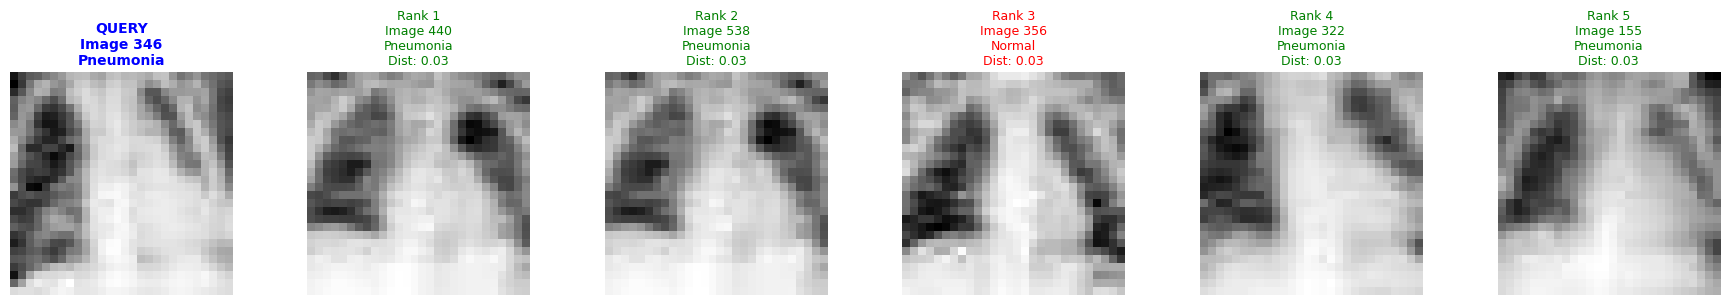

In [ ]:
# Interactive retrieval demo
print("="*80)
print("RETRIEVAL SYSTEM DEMO")
print("="*80)

# Select diverse query images
np.random.seed(42)
normal_samples = np.random.choice(np.where(all_labels == 0)[0], 3, replace=False)
pneumonia_samples = np.random.choice(np.where(all_labels == 1)[0], 3, replace=False)
demo_queries = np.concatenate([normal_samples, pneumonia_samples])

print(f"\nDemonstrating retrieval on {len(demo_queries)} sample queries...")

for query_idx in demo_queries:
    query_label = all_labels[query_idx]

    print(f"\n{'='*80}")
    print(f"Query Image {query_idx}: {'Pneumonia' if query_label == 1 else 'Normal'}")
    print('='*80)

    # Retrieve similar images
    distances, indices = search_similar_images(query_idx, index, embeddings, top_k=5)

    # Calculate precision
    precision = calculate_precision_at_k(query_idx, indices, all_labels, k=5)

    print(f"Precision@5: {precision:.2f}")
    print(f"\nTop 5 retrieved images:")
    for rank, (idx, dist) in enumerate(zip(indices, distances), 1):
        retrieved_label = all_labels[idx]
        match = "✓" if retrieved_label == query_label else "✗"
        print(f"  {rank}. Image {idx}: {'Pneumonia' if retrieved_label == 1 else 'Normal'} "
              f"(dist={dist:.3f}) {match}")

    # Visualize
    visualize_search_results(query_idx, indices, all_images, all_labels, distances)

In [ ]:
# Save all results
import json

results_summary = {
    "model": model_name,
    "embedding_dimension": int(embed_dim),
    "total_images": int(len(all_images)),
    "index_type": "FAISS Flat (L2)",
    "precision_at_k": {
        f"P@{k}": {
            "overall": float(np.mean(precision_results[k])),
            "std": float(np.std(precision_results[k])),
            "normal": float(np.mean([precision_results[k][i] for i in np.where(all_labels == 0)[0]])),
            "pneumonia": float(np.mean([precision_results[k][i] for i in np.where(all_labels == 1)[0]]))
        }
        for k in k_values
    }
}

# Save as JSON
with open('task3_results.json', 'w') as f:
    json.dump(results_summary, indent=2, fp=f)

print("✓ Results saved to 'task3_results.json'")

# Save detailed results
np.save('task3_precision_results.npy', precision_results)
print("✓ Detailed precision results saved to 'task3_precision_results.npy'")

# Create results text file
with open('task3_retrieval_results.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("TASK 3: SEMANTIC IMAGE RETRIEVAL SYSTEM RESULTS\n")
    f.write("="*80 + "\n\n")

    f.write(f"Model: {model_name}\n")
    f.write(f"Embedding Dimension: {embed_dim}\n")
    f.write(f"Total Images: {len(all_images)}\n")
    f.write(f"Index Type: FAISS Flat (L2)\n\n")

    f.write("="*80 + "\n")
    f.write("PRECISION@K RESULTS\n")
    f.write("="*80 + "\n\n")

    for k in k_values:
        avg_prec = np.mean(precision_results[k])
        std_prec = np.std(precision_results[k])
        f.write(f"Precision@{k}: {avg_prec:.4f} ± {std_prec:.4f}\n")

    f.write("\n" + "="*80 + "\n")
    f.write("PRECISION@K BY CLASS\n")
    f.write("="*80 + "\n\n")

    for k in k_values:
        normal_prec = np.mean([precision_results[k][i] for i in np.where(all_labels == 0)[0]])
        pneumonia_prec = np.mean([precision_results[k][i] for i in np.where(all_labels == 1)[0]])
        f.write(f"Precision@{k}:\n")
        f.write(f"  Normal:    {normal_prec:.4f}\n")
        f.write(f"  Pneumonia: {pneumonia_prec:.4f}\n\n")

print("✓ Results saved to 'task3_retrieval_results.txt'")

✓ Results saved to 'task3_results.json'
✓ Detailed precision results saved to 'task3_precision_results.npy'
✓ Results saved to 'task3_retrieval_results.txt'


In [ ]:
# Download all generated files
from google.colab import files

print("Preparing files for download...")

# List of files to download
download_files = [
    'image_embeddings.npy',
    'image_labels.npy',
    'image_embeddings.index',
    'task3_results.json',
    'task3_precision_results.npy',
    'task3_retrieval_results.txt',
    'task3_precision_at_k.png'
]

for filename in download_files:
    try:
        files.download(filename)
        print(f"✓ Downloaded: {filename}")
    except Exception as e:
        print(f"✗ Could not download {filename}: {e}")

print("\n✓ All files ready for download!")

Preparing files for download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: image_embeddings.npy


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Downloaded: task3_retrieval_results.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: task3_precision_at_k.png

✓ All files ready for download!


In [ ]:
print("\n" + "="*80)
print("TASK 3 COMPLETION SUMMARY")
print("="*80)

print(f"\n✓ Embedding Model: {model_name}")
print(f"✓ Embedding Dimension: {embed_dim}")
print(f"✓ Total Images Indexed: {len(all_images)}")
print(f"✓ Vector Database: FAISS (Flat L2)")

print(f"\n✓ Image-to-Image Search: Implemented")
print(f"✓ Text-to-Image Search: {'Implemented' if processor else 'Not implemented'}")

print(f"\n✓ Evaluation Metrics:")
for k in k_values:
    avg_prec = np.mean(precision_results[k])
    print(f"  Precision@{k}: {avg_prec:.4f}")

print(f"\n✓ Visualizations Created:")
print(f"  - Precision@k curves")
print(f"  - Sample retrieval results")
print(f"  - Failure case analysis")

print(f"\n✓ Files Generated:")
print(f"  - image_embeddings.npy (embeddings)")
print(f"  - image_embeddings.index (FAISS index)")
print(f"  - task3_results.json (summary)")
print(f"  - task3_retrieval_results.txt (detailed results)")
print(f"  - task3_precision_at_k.png (visualization)")

print("="*80)


TASK 3 COMPLETION SUMMARY

✓ Embedding Model: openai/clip-vit-base-patch32
✓ Embedding Dimension: 512
✓ Total Images Indexed: 624
✓ Vector Database: FAISS (Flat L2)

✓ Image-to-Image Search: Implemented
✓ Text-to-Image Search: Implemented

✓ Evaluation Metrics:
  Precision@1: 0.8029
  Precision@3: 0.7965
  Precision@5: 0.7833
  Precision@10: 0.7761

✓ Visualizations Created:
  - Precision@k curves
  - Sample retrieval results
  - Failure case analysis

✓ Files Generated:
  - image_embeddings.npy (embeddings)
  - image_embeddings.index (FAISS index)
  - task3_results.json (summary)
  - task3_retrieval_results.txt (detailed results)
  - task3_precision_at_k.png (visualization)
